<a href="https://colab.research.google.com/github/ART3MISH286/PRAHARI/blob/main/Copy_of_YOLO_PRAHARI1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!nvidia-smi

Mon Sep 28 18:53:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P0             28W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [5]:
!pip install -q ultralytics

In [6]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [7]:
from ultralytics import YOLO

print("YOLO successfully imported!")

YOLO successfully imported!


In [8]:
from google.colab import drive
import os

# Remove the mount point directory if it exists and is not empty
if os.path.exists('/content/drive') and os.path.isdir('/content/drive') and os.listdir('/content/drive'):
    print("Removing existing /content/drive mount point...")
    !rm -rf /content/drive/*
    !rmdir /content/drive

drive.mount('/content/drive', force_remount=True)

Removing existing /content/drive mount point...
Mounted at /content/drive


In [9]:
from pathlib import Path

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

DATASET1 = PRAHARI_ROOT / "datasets" / "dataset1"
DATASET2 = PRAHARI_ROOT / "datasets" / "dataset2"

MERGED = PRAHARI_ROOT / "merged"
RUNS = PRAHARI_ROOT / "runs"
MODELS = PRAHARI_ROOT / "models"

print("PRAHARI root :", PRAHARI_ROOT)
print("Dataset 1    :", DATASET1)
print("Dataset 2    :", DATASET2)
print("Merged       :", MERGED)
print("Runs         :", RUNS)
print("Models       :", MODELS)

PRAHARI root : /content/drive/MyDrive/PRAHARI
Dataset 1    : /content/drive/MyDrive/PRAHARI/datasets/dataset1
Dataset 2    : /content/drive/MyDrive/PRAHARI/datasets/dataset2
Merged       : /content/drive/MyDrive/PRAHARI/merged
Runs         : /content/drive/MyDrive/PRAHARI/runs
Models       : /content/drive/MyDrive/PRAHARI/models


In [10]:
for name, path in {
    "DATASET 1": DATASET1,
    "DATASET 2": DATASET2
}.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Exists:", path.exists())

    if path.exists():
        print("Contents:")
        for item in sorted(path.iterdir()):
            print("  ", item.name)


DATASET 1
Exists: True
Contents:
   WEAPON_DETECTION_FINAL.v3i.yolov11

DATASET 2
Exists: True
Contents:
   Yolo Weapon Detection.v1i.yolov11


In [11]:
import yaml
from pathlib import Path

# Actual YAML locations
DATASET1_YAML = DATASET1 / "WEAPON_DETECTION_FINAL.v3i.yolov11" / "data1.yaml"
DATASET2_YAML = DATASET2 / "Yolo Weapon Detection.v1i.yolov11" / "data2.yaml"

dataset_configs = {
    "DATASET 1": DATASET1_YAML,
    "DATASET 2": DATASET2_YAML
}

for name, yaml_path in dataset_configs.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("YAML:", yaml_path)
    print("Exists:", yaml_path.exists())

    if not yaml_path.exists():
        print("❌ YAML NOT FOUND")
        continue

    with open(yaml_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    print("\nClasses:")

    names = config.get("names", {})

    if isinstance(names, list):
        for i, class_name in enumerate(names):
            print(f"  {i}: {class_name}")
    else:
        for class_id, class_name in names.items():
            print(f"  {class_id}: {class_name}")

    print("\nPaths from YAML:")
    print("  train:", config.get("train"))
    print("  val  :", config.get("val"))
    print("  test :", config.get("test"))


DATASET 1
YAML: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml
Exists: True

Classes:
  0: Grenade
  1: Gun
  2: Knife
  3: Pistol

Paths from YAML:
  train: ../train/images
  val  : ../valid/images
  test : ../test/images

DATASET 2
YAML: /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml
Exists: True

Classes:
  0: Gunmen
  1: Rifle
  2: blunt object
  3: knife
  4: knife_attacker
  5: person
  6: pistol
  7: shot-gun
  8: submachine-gun

Paths from YAML:
  train: ../train/images
  val  : ../valid/images
  test : ../test/images


In [13]:
#Wrong cell
from pathlib import Path
import yaml

datasets = {
    "dataset1": DATASET1_YAML,
    "dataset2": DATASET2_YAML
}

resolved_paths = {}

for dataset_name, yaml_path in datasets.items():

    print("\n" + "=" * 70)
    print(f"{dataset_name.upper()} PATH VERIFICATION")
    print("=" * 70)

    # Load YAML
    with open(yaml_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    # YAML is located inside the actual dataset folder
    dataset_root = yaml_path.parent

    print("Dataset root:", dataset_root)

    resolved_paths[dataset_name] = {}

    for split_name, yaml_key in [
        ("train", "train"),
        ("valid", "val"),
        ("test", "test")
    ]:

        relative_path = config.get(yaml_key)

        if relative_path is None:
            print(f"\n{split_name.upper()}: ❌ path missing from YAML")
            continue

        # Resolve path relative to YAML location
        image_dir = (dataset_root / relative_path).resolve()

        # Convert .../images → .../labels
        label_dir = image_dir.parent / "labels"

        resolved_paths[dataset_name][split_name] = {
            "images": image_dir,
            "labels": label_dir
        }

        image_count = len([
            p for p in image_dir.iterdir()
            if p.is_file()
        ]) if image_dir.exists() else 0

        label_count = len(
            list(label_dir.glob("*.txt"))
        ) if label_dir.exists() else 0

        print(f"\n{split_name.upper()}")
        print("  Images:", image_dir)
        print("  Exists:", image_dir.exists())
        print("  Count :", image_count)

        print("  Labels:", label_dir)
        print("  Exists:", label_dir.exists())
        print("  Count :", label_count)


DATASET1 PATH VERIFICATION
Dataset root: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11

TRAIN
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/train/images
  Exists: False
  Count : 0
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/train/labels
  Exists: False
  Count : 0

VALID
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/valid/images
  Exists: False
  Count : 0
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/valid/labels
  Exists: False
  Count : 0

TEST
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/test/images
  Exists: False
  Count : 0
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/test/labels
  Exists: False
  Count : 0

DATASET2 PATH VERIFICATION
Dataset root: /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11

TRAIN
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset2/train/images
  Exists: False
  Count : 0
  Labels: /content/drive

In [14]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
from google.colab import drive

drive.flush_and_unmount()
print("Drive unmounted.")

Drive unmounted.


In [16]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [17]:
import os

print(os.path.exists("/content/drive/MyDrive"))
print(os.listdir("/content/drive/MyDrive")[:20])

True
['Colab Notebooks', 'dataset2_538_png.rf.cc6272299cc1f42a8b8d4b423b344d73.txt', 'dataset2_DefenseKnifeAttack0731_jpg.rf.e77302e7b5f191cc909c4824f0d8f0ea.txt', 'dataset2_shotgun-712-_jpg.rf.78da11ff1e4b476969ef08f031d59fe9.txt', 'dataset2_EALL0WD3DMVD_jpg.rf.73c275271fa794cef48007bb5e7c908f.txt', 'dataset2_shotgun-821-_jpg.rf.99be488f48d7263591330de71e7ed551.txt', 'dataset2_BB2MP5SD-3_jpg.rf.96dc9e0967b15d41319e5f4e07650a4c.txt', 'dataset2_LBmframe00271_jpg.rf.a20922914a2b3ea9d7a0c30536289edf.txt', 'dataset2_frame_0488_jpg.rf.d9ca5a5e48f28b559255ab51efdee3f1.txt', 'dataset2_frame_0819_jpg.rf.1dcbab31491ee1ae4413c9fe23bb7c67.txt', 'dataset2_4RLUT8V1XWB2_jpg.rf.b0882e2a8831c4ba12ab584b0e4a5aa3.txt', 'dataset2_6_22_4_0005328_jpg.rf.a901e38a56e6c814aa2e71c36cc92038.txt', 'dataset2_14_png.rf.cca066ae7da36c95568cb9b9e1f49555.txt', 'dataset2_KravMagaKnifeDefenseTechniques197_jpg.rf.de5ce1895130411c39b5e8fb2d8bc4c4.txt', 'dataset2_shotgun-857-_jpg.rf.e420409e752b62f8eeeb0f7d6f02c614.txt', 

In [18]:
print(os.path.exists("/content/drive/MyDrive/PRAHARI"))

True


In [19]:
print(os.listdir("/content/drive/MyDrive/PRAHARI/datasets"))

['dataset1', 'dataset2']


In [20]:
from pathlib import Path

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI/datasets")

files_to_remove = [
    PRAHARI_ROOT / "README.roboflow.txt",
    PRAHARI_ROOT / "data1.yaml",
    PRAHARI_ROOT / "README.dataset.txt",
]

for file in files_to_remove:
    if file.exists():
        file.unlink()
        print(f"🗑️ Deleted: {file.name}")
    else:
        print(f"⚠️ Not found: {file.name}")

print("\nRemaining PRAHARI contents:")
for item in PRAHARI_ROOT.iterdir():
    print("📁" if item.is_dir() else "📄", item.name)

⚠️ Not found: README.roboflow.txt
⚠️ Not found: data1.yaml
⚠️ Not found: README.dataset.txt

Remaining PRAHARI contents:
📁 dataset1
📁 dataset2


In [21]:
import os

DATASETS_ROOT = "/content/drive/MyDrive/PRAHARI/datasets"

for dataset in ["dataset1", "dataset2"]:
    path = os.path.join(DATASETS_ROOT, dataset)

    print("\n" + "=" * 70)
    print(dataset.upper())
    print("=" * 70)

    print("Path:", path)
    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        for item in os.listdir(path):
            full_path = os.path.join(path, item)
            print("📁" if os.path.isdir(full_path) else "📄", item)


DATASET1
Path: /content/drive/MyDrive/PRAHARI/datasets/dataset1
Exists: True
📁 WEAPON_DETECTION_FINAL.v3i.yolov11

DATASET2
Path: /content/drive/MyDrive/PRAHARI/datasets/dataset2
Exists: True
📁 Yolo Weapon Detection.v1i.yolov11


In [22]:
import os

DATASETS_ROOT = "/content/drive/MyDrive/PRAHARI/datasets"

dataset_paths = {
    "DATASET 1": os.path.join(
        DATASETS_ROOT,
        "dataset1",
        "WEAPON_DETECTION_FINAL.v3i.yolov11"
    ),
    "DATASET 2": os.path.join(
        DATASETS_ROOT,
        "dataset2",
        "Yolo Weapon Detection.v1i.yolov11"
    )
}

for name, path in dataset_paths.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Path:", path)
    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        print("\nContents:")

        for item in os.listdir(path):
            full_path = os.path.join(path, item)

            if os.path.isdir(full_path):
                print("📁", item)
            else:
                print("📄", item)


DATASET 1
Path: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11
Exists: True

Contents:
📄 README.roboflow.txt
📄 README.dataset.txt
📄 data1.yaml
📁 valid
📁 train
📁 test

DATASET 2
Path: /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11
Exists: True

Contents:
📄 data2.yaml
📄 README.roboflow.txt
📄 README.dataset.txt
📁 train
📁 valid
📁 test


In [23]:
from pathlib import Path
import yaml

DATASETS_ROOT = Path("/content/drive/MyDrive/PRAHARI/datasets")

DATASET1_YAML = (
    DATASETS_ROOT
    / "dataset1"
    / "WEAPON_DETECTION_FINAL.v3i.yolov11"
    / "data1.yaml"
)

DATASET2_YAML = (
    DATASETS_ROOT
    / "dataset2"
    / "Yolo Weapon Detection.v1i.yolov11"
    / "data2.yaml"
)

yaml_files = {
    "DATASET 1": DATASET1_YAML,
    "DATASET 2": DATASET2_YAML
}

for name, yaml_path in yaml_files.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("YAML:", yaml_path)
    print("Exists:", yaml_path.exists())

    with open(yaml_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    print("\n--- YAML CONFIGURATION ---")

    for key, value in config.items():
        print(f"{key}: {value!r}")


DATASET 1
YAML: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml
Exists: True

--- YAML CONFIGURATION ---
train: '../train/images'
val: '../valid/images'
test: '../test/images'
nc: 4
names: ['Grenade', 'Gun', 'Knife', 'Pistol']
roboflow: {'workspace': 'object-detection-lkq6h', 'project': 'weapon_detection_final-rvhn1', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/object-detection-lkq6h/weapon_detection_final-rvhn1/dataset/3'}

DATASET 2
YAML: /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml
Exists: True

--- YAML CONFIGURATION ---
train: '../train/images'
val: '../valid/images'
test: '../test/images'
nc: 9
names: ['Gunmen', 'Rifle', 'blunt object', 'knife', 'knife_attacker', 'person', 'pistol', 'shot-gun', 'submachine-gun']
roboflow: {'workspace': 'nisarga', 'project': 'yolo-weapon-detection-ntrwc', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.rob

In [24]:
from pathlib import Path

for path in [
    Path("/content/drive/MyDrive/PRAHARI/datasets/dataset1"),
    Path("/content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11"),
    Path("/content/drive/MyDrive/PRAHARI/datasets/dataset2"),
    Path("/content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11"),
]:

    print("\n", path)
    print("Exists:", path.exists())

    if path.exists():
        print("Contents:")
        for item in path.iterdir():
            print("  ", item.name)


 /content/drive/MyDrive/PRAHARI/datasets/dataset1
Exists: True
Contents:
   WEAPON_DETECTION_FINAL.v3i.yolov11

 /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11
Exists: True
Contents:
   README.roboflow.txt
   README.dataset.txt
   data1.yaml
   valid
   train
   test

 /content/drive/MyDrive/PRAHARI/datasets/dataset2
Exists: True
Contents:
   Yolo Weapon Detection.v1i.yolov11

 /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11
Exists: True
Contents:
   data2.yaml
   README.roboflow.txt
   README.dataset.txt
   train
   valid
   test


In [25]:
from pathlib import Path

# Actual dataset roots based on the folder structure we just verified
DATASET1_ROOT = DATASET1_YAML.parent
DATASET2_ROOT = DATASET2_YAML.parent

dataset_roots = {
    "DATASET 1": DATASET1_ROOT,
    "DATASET 2": DATASET2_ROOT
}

resolved_paths = {}

for name, dataset_root in dataset_roots.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Dataset root:")
    print(dataset_root)

    resolved_paths[name] = {}

    for split in ["train", "valid", "test"]:

        image_dir = dataset_root / split / "images"
        label_dir = dataset_root / split / "labels"

        image_count = len([
            p for p in image_dir.iterdir()
            if p.is_file()
        ]) if image_dir.exists() else 0

        label_count = len(
            list(label_dir.glob("*.txt"))
        ) if label_dir.exists() else 0

        resolved_paths[name][split] = {
            "images": image_dir,
            "labels": label_dir
        }

        print(f"\n{split.upper()}")
        print("  Images:", image_dir)
        print("  Exists:", image_dir.exists())
        print("  Count :", image_count)

        print("  Labels:", label_dir)
        print("  Exists:", label_dir.exists())
        print("  Count :", label_count)


DATASET 1
Dataset root:
/content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11

TRAIN
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/train/images
  Exists: True
  Count : 4195
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/train/labels
  Exists: True
  Count : 4195

VALID
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/valid/images
  Exists: True
  Count : 1361
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/valid/labels
  Exists: True
  Count : 1361

TEST
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/test/images
  Exists: True
  Count : 1264
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/test/labels
  Exists: True
  Count : 1264

DATASET 2
Dataset root:
/content/drive/MyDrive/PRA

In [26]:
# ============================================================
# CELL 5: ORIGINAL DATASET CLASS DISTRIBUTION
# ============================================================

import yaml
from pathlib import Path
from collections import Counter

dataset_info = {
    "dataset1": {
        "root": DATASET1_ROOT,
        "yaml": DATASET1_YAML
    },
    "dataset2": {
        "root": DATASET2_ROOT,
        "yaml": DATASET2_YAML
    }
}

for dataset_name, info in dataset_info.items():

    print("\n" + "=" * 75)
    print(f"{dataset_name.upper()} CLASS DISTRIBUTION")
    print("=" * 75)

    # Load YAML
    with open(info["yaml"], "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    names = config["names"]

    # Convert names to a consistent dictionary
    if isinstance(names, list):
        class_names = {
            i: name for i, name in enumerate(names)
        }
    else:
        class_names = {
            int(k): v for k, v in names.items()
        }

    print("\nClasses:")
    for class_id, class_name in class_names.items():
        print(f"  {class_id}: {class_name}")

    print("\nAnnotation counts:")

    for split in ["train", "valid", "test"]:

        label_dir = info["root"] / split / "labels"

        counts = Counter()
        malformed = 0
        total_annotations = 0

        for label_file in label_dir.glob("*.txt"):

            with open(label_file, "r", encoding="utf-8") as f:

                for line in f:

                    parts = line.strip().split()

                    if not parts:
                        continue

                    # At this stage we only want to identify the class.
                    try:
                        class_id = int(float(parts[0]))
                        counts[class_id] += 1
                        total_annotations += 1

                    except (ValueError, IndexError):
                        malformed += 1

        print(f"\n  {split.upper()}")
        print(f"  Total annotations: {total_annotations}")

        for class_id in sorted(class_names):

            print(
                f"    {class_id:2d} | "
                f"{class_names[class_id]:20s} | "
                f"{counts[class_id]}"
            )

        if malformed:
            print(
                f"  ⚠️ Malformed annotation lines: {malformed}"
            )


DATASET1 CLASS DISTRIBUTION

Classes:
  0: Grenade
  1: Gun
  2: Knife
  3: Pistol

Annotation counts:

  TRAIN
  Total annotations: 7160
     0 | Grenade              | 1995
     1 | Gun                  | 2047
     2 | Knife                | 1507
     3 | Pistol               | 1611

  VALID
  Total annotations: 2361
     0 | Grenade              | 637
     1 | Gun                  | 649
     2 | Knife                | 545
     3 | Pistol               | 530

  TEST
  Total annotations: 2212
     0 | Grenade              | 650
     1 | Gun                  | 630
     2 | Knife                | 442
     3 | Pistol               | 490

DATASET2 CLASS DISTRIBUTION

Classes:
  0: Gunmen
  1: Rifle
  2: blunt object
  3: knife
  4: knife_attacker
  5: person
  6: pistol
  7: shot-gun
  8: submachine-gun

Annotation counts:

  TRAIN
  Total annotations: 6267
     0 | Gunmen               | 1369
     1 | Rifle                | 613
     2 | blunt object         | 1
     3 | knife           

In [27]:
from pathlib import Path

# ============================================================
# PRAHARI DATASET PATHS
# ============================================================

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

DATASET1_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset1"
    / "WEAPON_DETECTION_FINAL.v3i.yolov11"
)

DATASET1_YAML = DATASET1_ROOT / "data1.yaml"

DATASET2_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset2"
    / "Yolo Weapon Detection.v1i.yolov11"
)

DATASET2_YAML = DATASET2_ROOT / "data2.yaml"


print("Dataset 1 root :", DATASET1_ROOT)
print("Dataset 1 YAML :", DATASET1_YAML)
print("Dataset 2 root :", DATASET2_ROOT)
print("Dataset 2 YAML :", DATASET2_YAML)

print("\nExistence check:")
print("Dataset 1:", DATASET1_ROOT.exists())
print("Dataset 1 YAML:", DATASET1_YAML.exists())
print("Dataset 2:", DATASET2_ROOT.exists())
print("Dataset 2 YAML:", DATASET2_YAML.exists())

Dataset 1 root : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11
Dataset 1 YAML : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml
Dataset 2 root : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11
Dataset 2 YAML : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml

Existence check:
Dataset 1: True
Dataset 1 YAML: True
Dataset 2: True
Dataset 2 YAML: True


In [28]:
from pathlib import Path

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

DATASET1_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset1"
    / "WEAPON_DETECTION_FINAL.v3i.yolov11"
)

DATASET1_YAML = DATASET1_ROOT / "data1.yaml"

DATASET2_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset2"
    / "Yolo Weapon Detection.v1i.yolov11"
)

DATASET2_YAML = DATASET2_ROOT / "data2.yaml"

print("DATASET 1 ROOT :", DATASET1_ROOT)
print("DATASET 1 YAML :", DATASET1_YAML)
print()
print("DATASET 2 ROOT :", DATASET2_ROOT)
print("DATASET 2 YAML :", DATASET2_YAML)

print("\n" + "=" * 60)
print("DRIVE VERIFICATION")
print("=" * 60)

print("PRAHARI exists :", PRAHARI_ROOT.exists())
print("Dataset 1     :", DATASET1_ROOT.exists())
print("Dataset 1 YAML :", DATASET1_YAML.exists())
print("Dataset 2     :", DATASET2_ROOT.exists())
print("Dataset 2 YAML :", DATASET2_YAML.exists())

DATASET 1 ROOT : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11
DATASET 1 YAML : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml

DATASET 2 ROOT : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11
DATASET 2 YAML : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml

DRIVE VERIFICATION
PRAHARI exists : True
Dataset 1     : True
Dataset 1 YAML : True
Dataset 2     : True
Dataset 2 YAML : True


In [29]:
# ============================================================
# CELL 6: PRAHARI 8-CLASS TAXONOMY
# ============================================================

PRAHARI_CLASSES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun",
}

# ------------------------------------------------------------
# DATASET 1
# ------------------------------------------------------------
# Original:
# 0 Grenade
# 1 Gun
# 2 Knife
# 3 Pistol

MAPPING_1 = {
    0: 5,       # Grenade -> grenade
    1: 1,       # Gun     -> gun
    2: 4,       # Knife   -> knife
    3: 2,       # Pistol  -> handgun
}

# ------------------------------------------------------------
# DATASET 2
# ------------------------------------------------------------
# Original:
# 0 Gunmen
# 1 Rifle
# 2 blunt object
# 3 knife
# 4 knife_attacker
# 5 person
# 6 pistol
# 7 shot-gun
# 8 submachine-gun

MAPPING_2 = {
    0: None,    # Gunmen         -> excluded
    1: 3,       # Rifle          -> rifle
    2: None,    # blunt object   -> excluded
    3: 4,       # knife          -> knife
    4: None,    # knife_attacker -> excluded
    5: 0,       # person         -> person
    6: 2,       # pistol         -> handgun
    7: 6,       # shot-gun       -> shotgun
    8: 7,       # submachine-gun -> submachine_gun
}

print("PRAHARI FINAL CLASS TAXONOMY")
print("=" * 50)

for class_id, class_name in PRAHARI_CLASSES.items():
    print(f"{class_id}: {class_name}")

print("\nDataset 1 mapping:")
for old, new in MAPPING_1.items():
    print(f"  {old} -> {new} ({PRAHARI_CLASSES[new]})")

print("\nDataset 2 mapping:")
for old, new in MAPPING_2.items():
    if new is None:
        print(f"  {old} -> EXCLUDED")
    else:
        print(f"  {old} -> {new} ({PRAHARI_CLASSES[new]})")

PRAHARI FINAL CLASS TAXONOMY
0: person
1: gun
2: handgun
3: rifle
4: knife
5: grenade
6: shotgun
7: submachine_gun

Dataset 1 mapping:
  0 -> 5 (grenade)
  1 -> 1 (gun)
  2 -> 4 (knife)
  3 -> 2 (handgun)

Dataset 2 mapping:
  0 -> EXCLUDED
  1 -> 3 (rifle)
  2 -> EXCLUDED
  3 -> 4 (knife)
  4 -> EXCLUDED
  5 -> 0 (person)
  6 -> 2 (handgun)
  7 -> 6 (shotgun)
  8 -> 7 (submachine_gun)


In [30]:
# ============================================================
# CELL 7: PRAHARI 8-CLASS MERGER DRY RUN
# ============================================================

from collections import Counter

DATASET_CONFIGS = {
    "dataset1": {
        "root": DATASET1_ROOT,
        "mapping": MAPPING_1
    },
    "dataset2": {
        "root": DATASET2_ROOT,
        "mapping": MAPPING_2
    }
}

dry_run_stats = {
    dataset: {
        split: {
            "images": 0,
            "usable_images": 0,
            "empty_images": 0,
            "usable_annotations": 0,
            "excluded_annotations": 0
        }
        for split in ["train", "valid", "test"]
    }
    for dataset in DATASET_CONFIGS
}

merged_class_counts = Counter()

for dataset_name, config in DATASET_CONFIGS.items():

    root = config["root"]
    mapping = config["mapping"]

    print("\n" + "=" * 70)
    print(f"DRY RUN: {dataset_name.upper()}")
    print("=" * 70)

    for split in ["train", "valid", "test"]:

        image_dir = root / split / "images"
        label_dir = root / split / "labels"

        image_files = [
            p for p in image_dir.iterdir()
            if p.is_file()
        ]

        stats = dry_run_stats[dataset_name][split]
        stats["images"] = len(image_files)

        for image_path in image_files:

            label_path = label_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                stats["empty_images"] += 1
                continue

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            usable_annotations = 0
            excluded_annotations = 0

            for line in lines:

                parts = line.strip().split()

                if not parts:
                    continue

                try:
                    old_class = int(float(parts[0]))
                except:
                    excluded_annotations += 1
                    continue

                if old_class not in mapping:
                    excluded_annotations += 1
                    continue

                new_class = mapping[old_class]

                if new_class is None:
                    excluded_annotations += 1
                    continue

                usable_annotations += 1
                merged_class_counts[new_class] += 1

            if usable_annotations > 0:

                stats["usable_images"] += 1
                stats["usable_annotations"] += usable_annotations
                stats["excluded_annotations"] += excluded_annotations

            else:

                stats["empty_images"] += 1


# ============================================================
# PRINT DATASET STATISTICS
# ============================================================

for dataset_name in DATASET_CONFIGS:

    print("\n" + "-" * 70)
    print(dataset_name.upper())

    for split in ["train", "valid", "test"]:

        s = dry_run_stats[dataset_name][split]

        print(f"\n{split.upper()}")
        print(f"  Original images       : {s['images']}")
        print(f"  Usable images         : {s['usable_images']}")
        print(f"  Empty/unusable images : {s['empty_images']}")
        print(f"  Usable annotations    : {s['usable_annotations']}")
        print(f"  Excluded annotations  : {s['excluded_annotations']}")


# ============================================================
# PROJECTED FINAL CLASS DISTRIBUTION
# ============================================================

print("\n\n" + "=" * 70)
print("PROJECTED PRAHARI CLASS DISTRIBUTION")
print("=" * 70)

for class_id, class_name in PRAHARI_CLASSES.items():

    print(
        f"{class_id}: "
        f"{class_name:18s} -> "
        f"{merged_class_counts[class_id]}"
    )


DRY RUN: DATASET1

DRY RUN: DATASET2

----------------------------------------------------------------------
DATASET1

TRAIN
  Original images       : 4195
  Usable images         : 3988
  Empty/unusable images : 207
  Usable annotations    : 7160
  Excluded annotations  : 0

VALID
  Original images       : 1361
  Usable images         : 1286
  Empty/unusable images : 75
  Usable annotations    : 2361
  Excluded annotations  : 0

TEST
  Original images       : 1264
  Usable images         : 1195
  Empty/unusable images : 69
  Usable annotations    : 2212
  Excluded annotations  : 0

----------------------------------------------------------------------
DATASET2

TRAIN
  Original images       : 3183
  Usable images         : 2875
  Empty/unusable images : 308
  Usable annotations    : 4237
  Excluded annotations  : 2023

VALID
  Original images       : 689
  Usable images         : 625
  Empty/unusable images : 64
  Usable annotations    : 939
  Excluded annotations  : 448

TEST
  Orig

In [31]:
from pathlib import Path
import yaml

DATASETS_ROOT = Path("/content/drive/MyDrive/PRAHARI/datasets")

yaml_files = {
    "DATASET1": (
        DATASETS_ROOT
        / "dataset1"
        / "WEAPON_DETECTION_FINAL.v3i.yolov11"
        / "data1.yaml"
    ),
    "DATASET2": (
        DATASETS_ROOT
        / "dataset2"
        / "Yolo Weapon Detection.v1i.yolov11"
        / "data2.yaml"
    )
}

for dataset_name, yaml_path in yaml_files.items():

    print("\n" + "=" * 70)
    print(dataset_name)
    print("=" * 70)

    with open(yaml_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    print("YAML path :", yaml_path)
    print("Train     :", config.get("train"))
    print("Val       :", config.get("val"))
    print("Test      :", config.get("test"))
    print("NC        :", config.get("nc"))
    print("Names     :", config.get("names"))

    print("\nClass ID mapping:")

    names = config.get("names", {})

    if isinstance(names, dict):
        for class_id, class_name in names.items():
            print(f"  {class_id} -> {class_name}")

    elif isinstance(names, list):
        for class_id, class_name in enumerate(names):
            print(f"  {class_id} -> {class_name}")


DATASET1
YAML path : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml
Train     : ../train/images
Val       : ../valid/images
Test      : ../test/images
NC        : 4
Names     : ['Grenade', 'Gun', 'Knife', 'Pistol']

Class ID mapping:
  0 -> Grenade
  1 -> Gun
  2 -> Knife
  3 -> Pistol

DATASET2
YAML path : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml
Train     : ../train/images
Val       : ../valid/images
Test      : ../test/images
NC        : 9
Names     : ['Gunmen', 'Rifle', 'blunt object', 'knife', 'knife_attacker', 'person', 'pistol', 'shot-gun', 'submachine-gun']

Class ID mapping:
  0 -> Gunmen
  1 -> Rifle
  2 -> blunt object
  3 -> knife
  4 -> knife_attacker
  5 -> person
  6 -> pistol
  7 -> shot-gun
  8 -> submachine-gun


In [32]:
##### ============================================================
# CELL 8: BUILD PRAHARI MERGED DATASET
# ============================================================

from pathlib import Path
import shutil
import yaml

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

MERGED_ROOT = PRAHARI_ROOT / "merged"

# Remove previous merged dataset if it exists
if MERGED_ROOT.exists():
    print(f"Removing previous merged dataset: {MERGED_ROOT}")
    shutil.rmtree(MERGED_ROOT)

# Create directory structure
for split in ["train", "valid", "test"]:
    (MERGED_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (MERGED_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

print(f"Created fresh merged dataset at:")
print(MERGED_ROOT)


# ------------------------------------------------------------
# PRAHARI class names
# ------------------------------------------------------------

PRAHARI_NAMES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun"
}


# ------------------------------------------------------------
# Merge datasets
# ------------------------------------------------------------

merge_stats = {
    dataset: {
        split: {
            "images": 0,
            "annotations": 0,
            "excluded_annotations": 0
        }
        for split in ["train", "valid", "test"]
    }
    for dataset in DATASET_CONFIGS
}


for dataset_name, config in DATASET_CONFIGS.items():

    root = config["root"]
    mapping = config["mapping"]

    print("\n" + "=" * 70)
    print(f"MERGING {dataset_name.upper()}")
    print("=" * 70)

    for split in ["train", "valid", "test"]:

        source_image_dir = root / split / "images"
        source_label_dir = root / split / "labels"

        output_image_dir = MERGED_ROOT / split / "images"
        output_label_dir = MERGED_ROOT / split / "labels"

        image_files = [
            p for p in source_image_dir.iterdir()
            if p.is_file()
        ]

        for image_path in image_files:

            label_path = source_label_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                continue

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            new_label_lines = []
            excluded_count = 0

            for line in lines:

                parts = line.strip().split()

                if not parts:
                    continue

                # Need at least class + 4 coordinates
                if len(parts) < 5:
                    excluded_count += 1
                    continue

                try:
                    old_class = int(float(parts[0]))
                except:
                    excluded_count += 1
                    continue

                # Unsupported / excluded class
                if old_class not in mapping:
                    excluded_count += 1
                    continue

                new_class = mapping[old_class]

                if new_class is None:
                    excluded_count += 1
                    continue

                # Preserve all coordinate values for now.
                coordinates = parts[1:]

                new_line = (
                    str(new_class)
                    + " "
                    + " ".join(coordinates)
                )

                new_label_lines.append(new_line)

            # If nothing usable remains, don't copy the image
            if not new_label_lines:
                continue

            # Prefix avoids filename collisions
            new_stem = f"{dataset_name}_{image_path.stem}"

            destination_image = (
                output_image_dir /
                f"{new_stem}{image_path.suffix}"
            )

            destination_label = (
                output_label_dir /
                f"{new_stem}.txt"
            )

            shutil.copy2(
                image_path,
                destination_image
            )

            destination_label.write_text(
                "\n".join(new_label_lines) + "\n",
                encoding="utf-8"
            )

            merge_stats[dataset_name][split]["images"] += 1
            merge_stats[dataset_name][split]["annotations"] += len(
                new_label_lines
            )
            merge_stats[dataset_name][split]["excluded_annotations"] += (
                excluded_count
            )


# ------------------------------------------------------------
# Create data.yaml
# ------------------------------------------------------------

data_yaml = {
    "path": str(MERGED_ROOT),

    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",

    "nc": len(PRAHARI_NAMES),

    "names": PRAHARI_NAMES
}

DATA_YAML = MERGED_ROOT / "data.yaml"

with open(DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False
    )


# ------------------------------------------------------------
# Print merge summary
# ------------------------------------------------------------

print("\n\n" + "=" * 70)
print("PRAHARI MERGE COMPLETE")
print("=" * 70)

for dataset_name in DATASET_CONFIGS:

    print(f"\n{dataset_name.upper()}")

    for split in ["train", "valid", "test"]:

        s = merge_stats[dataset_name][split]

        print(
            f"{split.upper():6s} | "
            f"images={s['images']:5d} | "
            f"annotations={s['annotations']:5d} | "
            f"excluded={s['excluded_annotations']:5d}"
        )

print("\n" + "=" * 70)
print("FINAL DATASET PATH")
print("=" * 70)

print(MERGED_ROOT)

print("\nDATA YAML:")
print(DATA_YAML)

print("\n" + "=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)

for split in ["train", "valid", "test"]:

    image_count = len(
        list((MERGED_ROOT / split / "images").iterdir())
    )

    label_count = len(
        list((MERGED_ROOT / split / "labels").iterdir())
    )

    print(
        f"{split:6s} -> "
        f"images: {image_count:5d} | "
        f"labels: {label_count:5d}"
    )

Removing previous merged dataset: /content/drive/MyDrive/PRAHARI/merged
Created fresh merged dataset at:
/content/drive/MyDrive/PRAHARI/merged

MERGING DATASET1


KeyboardInterrupt: 

In [33]:
# ============================================================
# CELL 8: BUILD PRAHARI MERGED DATASET
# ============================================================

from pathlib import Path
import shutil
import yaml

# ------------------------------------------------------------
# 1. PRAHARI ROOT
# ------------------------------------------------------------

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

# Dataset root
DATASETS_ROOT = PRAHARI_ROOT / "datasets"


# ------------------------------------------------------------
# 2. SOURCE DATASET PATHS
# ------------------------------------------------------------

DATASET1_ROOT = (
    DATASETS_ROOT
    / "dataset1"
    / "WEAPON_DETECTION_FINAL.v3i.yolov11"
)

DATASET2_ROOT = (
    DATASETS_ROOT
    / "dataset2"
    / "Yolo Weapon Detection.v1i.yolov11"
)


# ------------------------------------------------------------
# 3. VERIFY SOURCE DATASETS
# ------------------------------------------------------------

print("=" * 70)
print("VERIFYING SOURCE DATASETS")
print("=" * 70)

for name, root in {
    "DATASET 1": DATASET1_ROOT,
    "DATASET 2": DATASET2_ROOT
}.items():

    print(f"\n{name}")
    print("Path   :", root)
    print("Exists :", root.exists())

    if not root.exists():
        raise FileNotFoundError(
            f"{name} not found at:\n{root}"
        )


# ------------------------------------------------------------
# 4. PRAHARI UNIFIED CLASS NAMES
# ------------------------------------------------------------

PRAHARI_NAMES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun"
}


# ------------------------------------------------------------
# 5. DATASET CLASS MAPPINGS
#
# Dataset 1:
# 0 -> Grenade
# 1 -> Gun
# 2 -> Knife
# 3 -> Pistol
#
# Dataset 2:
# 0 -> Gunmen
# 1 -> Rifle
# 2 -> blunt object
# 3 -> knife
# 4 -> knife_attacker
# 5 -> person
# 6 -> pistol
# 7 -> shot-gun
# 8 -> submachine-gun
# ------------------------------------------------------------

DATASET_CONFIGS = {

    "dataset1": {
        "root": DATASET1_ROOT,

        "mapping": {
            0: 5,       # Grenade       -> grenade
            1: 1,       # Gun            -> gun
            2: 4,       # Knife          -> knife
            3: 2        # Pistol         -> handgun
        }
    },

    "dataset2": {
        "root": DATASET2_ROOT,

        "mapping": {
            0: 0,       # Gunmen         -> person
            1: 3,       # Rifle          -> rifle
            2: None,    # blunt object   -> excluded
            3: 4,       # knife          -> knife
            4: None,    # knife_attacker -> excluded
            5: 0,       # person         -> person
            6: 2,       # pistol         -> handgun
            7: 6,       # shot-gun       -> shotgun
            8: 7        # submachine-gun -> submachine_gun
        }
    }
}


# ------------------------------------------------------------
# 6. OUTPUT DIRECTORY
# ------------------------------------------------------------

MERGED_ROOT = PRAHARI_ROOT / "merged"


# Remove previous merged dataset
if MERGED_ROOT.exists():

    print("\n" + "=" * 70)
    print("REMOVING PREVIOUS MERGED DATASET")
    print("=" * 70)

    print(MERGED_ROOT)

    shutil.rmtree(MERGED_ROOT)


# Create directory structure
for split in ["train", "valid", "test"]:

    (MERGED_ROOT / split / "images").mkdir(
        parents=True,
        exist_ok=True
    )

    (MERGED_ROOT / split / "labels").mkdir(
        parents=True,
        exist_ok=True
    )


print("\n" + "=" * 70)
print("MERGED DATASET DIRECTORY CREATED")
print("=" * 70)

print(MERGED_ROOT)


# ------------------------------------------------------------
# 7. MERGE STATISTICS
# ------------------------------------------------------------

merge_stats = {

    dataset: {

        split: {
            "images": 0,
            "annotations": 0,
            "excluded_annotations": 0,
            "missing_labels": 0
        }

        for split in ["train", "valid", "test"]
    }

    for dataset in DATASET_CONFIGS
}


# ------------------------------------------------------------
# 8. MERGE DATASETS
# ------------------------------------------------------------

for dataset_name, config in DATASET_CONFIGS.items():

    root = config["root"]
    mapping = config["mapping"]

    print("\n" + "=" * 70)
    print(f"MERGING {dataset_name.upper()}")
    print("=" * 70)

    for split in ["train", "valid", "test"]:

        source_image_dir = root / split / "images"
        source_label_dir = root / split / "labels"

        output_image_dir = (
            MERGED_ROOT / split / "images"
        )

        output_label_dir = (
            MERGED_ROOT / split / "labels"
        )


        # Verify source directories
        if not source_image_dir.exists():

            print(
                f"⚠️ Missing image directory: "
                f"{source_image_dir}"
            )

            continue


        if not source_label_dir.exists():

            print(
                f"⚠️ Missing label directory: "
                f"{source_label_dir}"
            )

            continue


        image_files = [
            p for p in source_image_dir.iterdir()
            if p.is_file()
        ]


        for image_path in image_files:

            label_path = (
                source_label_dir
                / f"{image_path.stem}.txt"
            )


            # ------------------------------------------------
            # Missing annotation file
            # ------------------------------------------------

            if not label_path.exists():

                merge_stats[dataset_name][split][
                    "missing_labels"
                ] += 1

                continue


            # ------------------------------------------------
            # Read annotations
            # ------------------------------------------------

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()


            new_label_lines = []

            excluded_count = 0


            for line in lines:

                parts = line.strip().split()


                # Empty line
                if not parts:
                    continue


                # YOLO format requires:
                # class x_center y_center width height

                if len(parts) < 5:

                    excluded_count += 1
                    continue


                # ------------------------------------------------
                # Read original class ID
                # ------------------------------------------------

                try:

                    old_class = int(
                        float(parts[0])
                    )

                except (ValueError, TypeError):

                    excluded_count += 1
                    continue


                # ------------------------------------------------
                # Check mapping
                # ------------------------------------------------

                if old_class not in mapping:

                    excluded_count += 1
                    continue


                new_class = mapping[old_class]


                # Explicitly excluded class
                if new_class is None:

                    excluded_count += 1
                    continue


                # ------------------------------------------------
                # Preserve YOLO coordinates
                # ------------------------------------------------

                coordinates = parts[1:]


                new_line = (
                    str(new_class)
                    + " "
                    + " ".join(coordinates)
                )


                new_label_lines.append(new_line)


            # ------------------------------------------------
            # Skip image if no usable annotations remain
            # ------------------------------------------------

            if not new_label_lines:

                continue


            # ------------------------------------------------
            # Collision-safe filename
            # ------------------------------------------------

            new_stem = (
                f"{dataset_name}_{image_path.stem}"
            )


            destination_image = (
                output_image_dir
                / f"{new_stem}{image_path.suffix}"
            )


            destination_label = (
                output_label_dir
                / f"{new_stem}.txt"
            )


            # ------------------------------------------------
            # Copy image
            # ------------------------------------------------

            shutil.copy2(
                image_path,
                destination_image
            )


            # ------------------------------------------------
            # Write converted labels
            # ------------------------------------------------

            destination_label.write_text(
                "\n".join(new_label_lines) + "\n",
                encoding="utf-8"
            )


            # ------------------------------------------------
            # Update statistics
            # ------------------------------------------------

            merge_stats[dataset_name][split][
                "images"
            ] += 1

            merge_stats[dataset_name][split][
                "annotations"
            ] += len(new_label_lines)

            merge_stats[dataset_name][split][
                "excluded_annotations"
            ] += excluded_count


# ------------------------------------------------------------
# 9. CREATE PRAHARI data.yaml
# ------------------------------------------------------------

data_yaml = {

    "path": str(MERGED_ROOT),

    "train": "train/images",

    "val": "valid/images",

    "test": "test/images",

    "nc": len(PRAHARI_NAMES),

    "names": list(PRAHARI_NAMES.values())
}


DATA_YAML = MERGED_ROOT / "data.yaml"


with open(
    DATA_YAML,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False
    )


# ------------------------------------------------------------
# 10. PRINT MERGE SUMMARY
# ------------------------------------------------------------

print("\n\n" + "=" * 70)
print("PRAHARI MERGE COMPLETE")
print("=" * 70)


for dataset_name in DATASET_CONFIGS:

    print(f"\n{dataset_name.upper()}")

    for split in ["train", "valid", "test"]:

        stats = merge_stats[
            dataset_name
        ][split]


        print(
            f"{split.upper():6s} | "
            f"images={stats['images']:5d} | "
            f"annotations={stats['annotations']:5d} | "
            f"excluded={stats['excluded_annotations']:5d} | "
            f"missing_labels={stats['missing_labels']:4d}"
        )


# ------------------------------------------------------------
# 11. FINAL DATASET STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET STRUCTURE")
print("=" * 70)


for split in ["train", "valid", "test"]:

    image_dir = MERGED_ROOT / split / "images"
    label_dir = MERGED_ROOT / split / "labels"


    image_count = len(
        list(image_dir.iterdir())
    )


    label_count = len(
        list(label_dir.iterdir())
    )


    print(
        f"{split:6s} -> "
        f"images: {image_count:5d} | "
        f"labels: {label_count:5d}"
    )


# ------------------------------------------------------------
# 12. FINAL PATHS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PRAHARI MERGED DATASET")
print("=" * 70)

print("Dataset root:")
print(MERGED_ROOT)

print("\nData YAML:")
print(DATA_YAML)

print("\nPRAHARI classes:")

for class_id, class_name in PRAHARI_NAMES.items():

    print(
        f"  {class_id}: {class_name}"
    )

print("\n" + "=" * 70)
print("READY FOR DATASET VALIDATION")
print("=" * 70)


VERIFYING SOURCE DATASETS

DATASET 1
Path   : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11
Exists : True

DATASET 2
Path   : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11
Exists : True

REMOVING PREVIOUS MERGED DATASET
/content/drive/MyDrive/PRAHARI/merged

MERGED DATASET DIRECTORY CREATED
/content/drive/MyDrive/PRAHARI/merged

MERGING DATASET1

MERGING DATASET2


PRAHARI MERGE COMPLETE

DATASET1
TRAIN  | images= 3988 | annotations= 7160 | excluded=    0 | missing_labels=   0
VALID  | images= 1286 | annotations= 2361 | excluded=    0 | missing_labels=   0
TEST   | images= 1195 | annotations= 2212 | excluded=    0 | missing_labels=   0

DATASET2
TRAIN  | images= 2875 | annotations= 5606 | excluded=  654 | missing_labels=   0
VALID  | images=  625 | annotations= 1234 | excluded=  153 | missing_labels=   0
TEST   | images=  640 | annotations= 1217 | excluded=  155 | missing_labels=   0

FINAL DATASET STRUCTURE
tra

In [34]:
# ============================================================
# CELL 9: SAVE PRAHARI DATASET MERGER TO DRIVE
# ============================================================

from pathlib import Path

PROJECT_SCRIPTS = PRAHARI_ROOT / "scripts"
PROJECT_DOCS = PRAHARI_ROOT / "docs"

PROJECT_SCRIPTS.mkdir(parents=True, exist_ok=True)
PROJECT_DOCS.mkdir(parents=True, exist_ok=True)

MERGE_SCRIPT = PROJECT_SCRIPTS / "merge_prahari_dataset.py"

merge_script_content = r'''from pathlib import Path
from collections import Counter
import shutil
import yaml


# ============================================================
# PRAHARI DATASET MERGER
# ============================================================

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

DATASET1_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset1"
    / "WEAPON_DETECTION_FINAL.v3i.yolov11"
)

DATASET2_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset2"
    / "Yolo Weapon Detection.v1i.yolov11"
)

MERGED_ROOT = PRAHARI_ROOT / "merged"


# ============================================================
# PRAHARI FINAL CLASS TAXONOMY
# ============================================================

PRAHARI_CLASSES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun",
}


# ============================================================
# DATASET CLASS MAPPINGS
# ============================================================

MAPPING_1 = {
    0: 5,       # Grenade -> grenade
    1: 1,       # Gun -> gun
    2: 4,       # Knife -> knife
    3: 2,       # Pistol -> handgun
}

MAPPING_2 = {
    0: None,    # Gunmen -> excluded
    1: 3,       # Rifle -> rifle
    2: None,    # blunt object -> excluded
    3: 4,       # knife -> knife
    4: None,    # knife_attacker -> excluded
    5: 0,       # person -> person
    6: 2,       # pistol -> handgun
    7: 6,       # shot-gun -> shotgun
    8: 7,       # submachine-gun -> submachine_gun
}


DATASET_CONFIGS = {
    "dataset1": {
        "root": DATASET1_ROOT,
        "mapping": MAPPING_1,
    },
    "dataset2": {
        "root": DATASET2_ROOT,
        "mapping": MAPPING_2,
    },
}


# ============================================================
# CREATE FRESH MERGED DATASET
# ============================================================

if MERGED_ROOT.exists():
    shutil.rmtree(MERGED_ROOT)

for split in ["train", "valid", "test"]:
    (MERGED_ROOT / split / "images").mkdir(
        parents=True,
        exist_ok=True
    )
    (MERGED_ROOT / split / "labels").mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# MERGE
# ============================================================

for dataset_name, config in DATASET_CONFIGS.items():

    root = config["root"]
    mapping = config["mapping"]

    for split in ["train", "valid", "test"]:

        source_image_dir = root / split / "images"
        source_label_dir = root / split / "labels"

        output_image_dir = MERGED_ROOT / split / "images"
        output_label_dir = MERGED_ROOT / split / "labels"

        image_files = [
            p for p in source_image_dir.iterdir()
            if p.is_file()
        ]

        for image_path in image_files:

            label_path = source_label_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                continue

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            new_label_lines = []

            for line in lines:

                parts = line.strip().split()

                if len(parts) < 5:
                    continue

                try:
                    old_class = int(float(parts[0]))
                except ValueError:
                    continue

                if old_class not in mapping:
                    continue

                new_class = mapping[old_class]

                if new_class is None:
                    continue

                coordinates = parts[1:]

                new_label_lines.append(
                    str(new_class)
                    + " "
                    + " ".join(coordinates)
                )

            if not new_label_lines:
                continue

            new_stem = f"{dataset_name}_{image_path.stem}"

            destination_image = (
                output_image_dir
                / f"{new_stem}{image_path.suffix}"
            )

            destination_label = (
                output_label_dir
                / f"{new_stem}.txt"
            )

            shutil.copy2(
                image_path,
                destination_image
            )

            destination_label.write_text(
                "\n".join(new_label_lines) + "\n",
                encoding="utf-8"
            )


# ============================================================
# CREATE YOLO DATA CONFIGURATION
# ============================================================

data_yaml = {
    "path": str(MERGED_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(PRAHARI_CLASSES),
    "names": PRAHARI_CLASSES,
}

DATA_YAML = MERGED_ROOT / "data.yaml"

with open(DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False
    )


print("PRAHARI dataset merge completed.")
print(f"Merged dataset: {MERGED_ROOT}")
print(f"Data YAML:      {DATA_YAML}")
'''


MERGE_SCRIPT.write_text(
    merge_script_content,
    encoding="utf-8"
)

print("Saved:")
print(MERGE_SCRIPT)

Saved:
/content/drive/MyDrive/PRAHARI/scripts/merge_prahari_dataset.py


In [35]:
# ============================================================
# CELL 10: SAVE PRAHARI IMPLEMENTATION PROGRESS
# ============================================================

PROGRESS_FILE = PROJECT_DOCS / "implementation_progress.md"

progress = r'''# PRAHARI Implementation Progress

## Date

2026-09-21

## Current Phase

Visual threat detection dataset preparation.

---

## Project Scope

PRAHARI is being implemented as a security-focused AI system for visual threat detection and operator assistance.

Current prototype pipeline:

```text
Input Image / Video
        |
        v
YOLO Threat Detector
        |
        v
Confidence Filtering
        |
        v
Threat Assessment
        |
        v
Explainability
        |
        v
Voice Alert
        |
        v
Operator Dashboard

_IncompleteInputError: incomplete input (1227505213.py, line 7)

In [36]:
# ============================================================
# CELL 10: SAVE PRAHARI IMPLEMENTATION PROGRESS
# ============================================================

from pathlib import Path

PROJECT_DOCS = PRAHARI_ROOT / "docs"
PROJECT_DOCS.mkdir(parents=True, exist_ok=True)

PROGRESS_FILE = PROJECT_DOCS / "implementation_progress.md"

progress_lines = [
    "# PRAHARI Implementation Progress",
    "",
    "## Date",
    "",
    "2026-09-21",
    "",
    "## Current Phase",
    "",
    "Visual threat detection dataset preparation.",
    "",
    "## Project Scope",
    "",
    "PRAHARI is being implemented as a security-focused AI system for visual threat detection and operator assistance.",
    "",
    "Current prototype pipeline:",
    "",
    "Input Image / Video",
    "        |",
    "        v",
    "YOLO Threat Detector",
    "        |",
    "        v",
    "Confidence Filtering",
    "        |",
    "        v",
    "Threat Assessment",
    "        |",
    "        v",
    "Explainability",
    "        |",
    "        v",
    "Voice Alert",
    "        |",
    "        v",
    "Operator Dashboard",
    "",
    "Future extensions include thermal, LiDAR, radar, RF, acoustic and multimodal sensing.",
    "",
    "## Dataset Preparation",
    "",
    "Two YOLO-format datasets are being merged.",
    "",
    "### Dataset 1",
    "",
    "WEAPON_DETECTION_FINAL.v3i.yolov11",
    "",
    "Original classes:",
    "",
    "0 = Grenade",
    "1 = Gun",
    "2 = Knife",
    "3 = Pistol",
    "",
    "Mapping:",
    "",
    "0 -> 5  grenade",
    "1 -> 1  gun",
    "2 -> 4  knife",
    "3 -> 2  handgun",
    "",
    "Original image counts:",
    "",
    "Train = 4195",
    "Valid = 1361",
    "Test  = 1264",
    "",
    "Usable image counts after class filtering:",
    "",
    "Train = 3988",
    "Valid = 1286",
    "Test  = 1195",
    "",
    "### Dataset 2",
    "",
    "Yolo Weapon Detection.v1i.yolov11",
    "",
    "Original classes:",
    "",
    "0 = Gunmen",
    "1 = Rifle",
    "2 = blunt object",
    "3 = knife",
    "4 = knife_attacker",
    "5 = person",
    "6 = pistol",
    "7 = shot-gun",
    "8 = submachine-gun",
    "",
    "Mapping:",
    "",
    "0 -> excluded",
    "1 -> 3  rifle",
    "2 -> excluded",
    "3 -> 4  knife",
    "4 -> excluded",
    "5 -> 0  person",
    "6 -> 2  handgun",
    "7 -> 6  shotgun",
    "8 -> 7  submachine_gun",
    "",
    "The excluded classes are removed at annotation level.",
    "",
    "If an image contains both supported and excluded annotations, the supported annotations are retained.",
    "",
    "If an image contains no supported annotations, the image is excluded from the merged dataset.",
    "",
    "## Final PRAHARI Taxonomy",
    "",
    "0 = person",
    "1 = gun",
    "2 = handgun",
    "3 = rifle",
    "4 = knife",
    "5 = grenade",
    "6 = shotgun",
    "7 = submachine_gun",
    "",
    "Total classes = 8",
    "",
    "## Merged Dataset",
    "",
    "Final merged dataset location:",
    "",
    "/content/drive/MyDrive/PRAHARI/merged",
    "",
    "Final image counts:",
    "",
    "Train = 6863",
    "Valid = 1911",
    "Test  = 1835",
    "Total = 10609 images",
    "",
    "Image-label correspondence:",
    "",
    "Train = 6863 images / 6863 labels",
    "Valid = 1911 images / 1911 labels",
    "Test  = 1835 images / 1835 labels",
    "",
    "## Projected Annotation Distribution",
    "",
    "person             = 2271",
    "gun                = 3326",
    "handgun            = 4114",
    "rifle              = 826",
    "knife              = 3488",
    "grenade            = 3282",
    "shotgun            = 491",
    "submachine_gun     = 46",
    "",
    "The submachine_gun class is retained but is highly underrepresented and will be evaluated separately.",
    "",
    "## Current Status",
    "",
    "Completed:",
    "",
    "- Google Drive dataset organization",
    "- Dataset 1 inspection",
    "- Dataset 2 inspection",
    "- Original class-distribution analysis",
    "- PRAHARI 8-class taxonomy definition",
    "- Dataset class mappings",
    "- Dry-run merger",
    "- Actual dataset merger",
    "- Merged dataset structure creation",
    "- YOLO data.yaml creation",
    "",
    "Not yet completed:",
    "",
    "- Merged annotation integrity validation",
    "- Polygon/segmentation annotation detection and repair if required",
    "- Ground-truth visualization",
    "- YOLO environment/GPU verification",
    "- YOLO11n baseline training",
    "- Validation and test evaluation",
    "- Confusion matrix",
    "- PR curves",
    "- Per-class metrics",
    "- Inference/FPS measurements",
    "- Explainability module",
    "- Voice alert module",
    "- Operator dashboard",
    "- Final GitHub documentation",
    "- Research-paper experiments",
    "",
    "## Reproducibility",
    "",
    "Large datasets, model weights and training runs should remain outside the Git repository.",
    "",
    "Google Drive stores:",
    "",
    "datasets/",
    "merged/",
    "runs/",
    "models/",
    "",
    "GitHub stores:",
    "",
    "scripts/",
    "configs/",
    "detection/",
    "explainability/",
    "voice_alert/",
    "dashboard/",
    "docs/",
    "README.md",
    "",
    "This keeps the repository lightweight and reproducible.",
]

PROGRESS_FILE.write_text(
    "\n".join(progress_lines),
    encoding="utf-8"
)

print("Progress document saved successfully.")
print(PROGRESS_FILE)
print()
print("File size:", PROGRESS_FILE.stat().st_size, "bytes")

Progress document saved successfully.
/content/drive/MyDrive/PRAHARI/docs/implementation_progress.md

File size: 3500 bytes


In [37]:
# ============================================================
# CELL 11: VERIFY GITHUB-BOUND PROJECT FILES
# ============================================================

print("=" * 70)
print("PRAHARI GITHUB FILE VERIFICATION")
print("=" * 70)

files_to_verify = [
    MERGE_SCRIPT,
    PROGRESS_FILE,
]

all_exist = True

for file_path in files_to_verify:

    exists = file_path.exists()

    print(f"\n{file_path}")
    print(f"Exists: {exists}")

    if exists:
        print(f"Size  : {file_path.stat().st_size:,} bytes")
    else:
        all_exist = False

print("\n" + "=" * 70)

if all_exist:
    print("STATUS: READY TO COPY TO GITHUB REPOSITORY")
else:
    print("STATUS: ONE OR MORE FILES ARE MISSING")

PRAHARI GITHUB FILE VERIFICATION

/content/drive/MyDrive/PRAHARI/scripts/merge_prahari_dataset.py
Exists: True
Size  : 5,077 bytes

/content/drive/MyDrive/PRAHARI/docs/implementation_progress.md
Exists: True
Size  : 3,500 bytes

STATUS: READY TO COPY TO GITHUB REPOSITORY


In [38]:
# ============================================================
# CELL 12: VERIFY PRAHARI DRIVE PROJECT FILES
# ============================================================

from pathlib import Path

print("=" * 70)
print("PRAHARI DRIVE STRUCTURE")
print("=" * 70)

for folder in [
    PRAHARI_ROOT,
    PRAHARI_ROOT / "scripts",
    PRAHARI_ROOT / "docs",
    PRAHARI_ROOT / "datasets",
    PRAHARI_ROOT / "merged",
]:
    print(f"{folder}")
    print(f"  Exists: {folder.exists()}")
    print()

print("=" * 70)
print("PROJECT FILES")
print("=" * 70)

for file_path in [
    PRAHARI_ROOT / "scripts" / "merge_prahari_dataset.py",
    PRAHARI_ROOT / "docs" / "implementation_progress.md",
    PRAHARI_ROOT / "merged" / "data.yaml",
]:
    print(f"\n{file_path}")
    print(f"  Exists: {file_path.exists()}")

    if file_path.exists():
        print(f"  Size  : {file_path.stat().st_size:,} bytes")

PRAHARI DRIVE STRUCTURE
/content/drive/MyDrive/PRAHARI
  Exists: True

/content/drive/MyDrive/PRAHARI/scripts
  Exists: True

/content/drive/MyDrive/PRAHARI/docs
  Exists: True

/content/drive/MyDrive/PRAHARI/datasets
  Exists: True

/content/drive/MyDrive/PRAHARI/merged
  Exists: True

PROJECT FILES

/content/drive/MyDrive/PRAHARI/scripts/merge_prahari_dataset.py
  Exists: True
  Size  : 5,077 bytes

/content/drive/MyDrive/PRAHARI/docs/implementation_progress.md
  Exists: True
  Size  : 3,500 bytes

/content/drive/MyDrive/PRAHARI/merged/data.yaml
  Exists: True
  Size  : 191 bytes


In [39]:
# ============================================================
# CELL 13: VERIFY MERGED FOLDER FROM COLAB
# ============================================================

from pathlib import Path

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

print("=" * 70)
print("MERGED FOLDER CONTENTS")
print("=" * 70)

for item in sorted(MERGED_ROOT.iterdir()):
    if item.is_dir():
        print(f"[DIR ]  {item.name}/")
    else:
        print(f"[FILE]  {item.name}   ({item.stat().st_size:,} bytes)")

print("\n" + "=" * 70)
print("DATA.YAML CHECK")
print("=" * 70)

DATA_YAML = MERGED_ROOT / "data.yaml"

print("Path   :", DATA_YAML)
print("Exists :", DATA_YAML.exists())

if DATA_YAML.exists():
    print("Size   :", DATA_YAML.stat().st_size, "bytes")
    print("\nCONTENT:")
    print("-" * 50)
    print(DATA_YAML.read_text(encoding="utf-8"))

MERGED FOLDER CONTENTS
[FILE]  data.yaml   (191 bytes)
[DIR ]  test/
[DIR ]  train/
[DIR ]  valid/

DATA.YAML CHECK
Path   : /content/drive/MyDrive/PRAHARI/merged/data.yaml
Exists : True
Size   : 191 bytes

CONTENT:
--------------------------------------------------
path: /content/drive/MyDrive/PRAHARI/merged
train: train/images
val: valid/images
test: test/images
nc: 8
names:
- person
- gun
- handgun
- rifle
- knife
- grenade
- shotgun
- submachine_gun



In [40]:
# ============================================================
# CELL 14: PRAHARI MERGED DATASET INTEGRITY VALIDATION
# ============================================================

from pathlib import Path
from collections import Counter

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

VALID_CLASS_IDS = set(range(8))

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

validation_results = {}

print("=" * 75)
print("PRAHARI MERGED DATASET INTEGRITY VALIDATION")
print("=" * 75)

for split in ["train", "valid", "test"]:

    image_dir = MERGED_ROOT / split / "images"
    label_dir = MERGED_ROOT / split / "labels"

    image_files = sorted([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    label_files = sorted([
        p for p in label_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ])

    image_stems = {p.stem for p in image_files}
    label_stems = {p.stem for p in label_files}

    missing_labels = sorted(image_stems - label_stems)
    orphan_labels = sorted(label_stems - image_stems)

    stats = {
        "images": len(image_files),
        "labels": len(label_files),
        "missing_labels": len(missing_labels),
        "orphan_labels": len(orphan_labels),
        "empty_labels": 0,
        "valid_annotations": 0,
        "invalid_annotations": 0,
        "polygon_annotations": 0,
        "invalid_class_ids": 0,
        "invalid_coordinates": 0,
        "non_numeric_values": 0,
    }

    class_counts = Counter()

    polygon_examples = []
    invalid_examples = []

    # --------------------------------------------------------
    # Validate every label file
    # --------------------------------------------------------

    for label_path in label_files:

        text = label_path.read_text(
            encoding="utf-8"
        )

        lines = [
            line.strip()
            for line in text.splitlines()
            if line.strip()
        ]

        if not lines:
            stats["empty_labels"] += 1
            continue

        for line_number, line in enumerate(lines, start=1):

            parts = line.split()

            # Standard YOLO detection:
            # class + x_center + y_center + width + height
            if len(parts) != 5:

                stats["invalid_annotations"] += 1

                # More than 5 values may indicate polygon
                # / segmentation-style annotation.
                if len(parts) > 5:

                    stats["polygon_annotations"] += 1

                    if len(polygon_examples) < 10:
                        polygon_examples.append(
                            (
                                str(label_path),
                                line_number,
                                len(parts),
                                line
                            )
                        )

                elif len(invalid_examples) < 10:

                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            # ------------------------------------------------
            # Class ID
            # ------------------------------------------------

            try:
                class_id = int(float(parts[0]))
            except ValueError:

                stats["invalid_annotations"] += 1
                stats["non_numeric_values"] += 1

                if len(invalid_examples) < 10:
                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            if class_id not in VALID_CLASS_IDS:

                stats["invalid_annotations"] += 1
                stats["invalid_class_ids"] += 1

                if len(invalid_examples) < 10:
                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            # ------------------------------------------------
            # Coordinates
            # ------------------------------------------------

            try:
                coordinates = [
                    float(value)
                    for value in parts[1:]
                ]
            except ValueError:

                stats["invalid_annotations"] += 1
                stats["non_numeric_values"] += 1

                if len(invalid_examples) < 10:
                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            # YOLO normalized coordinates must be [0, 1]
            if any(
                value < 0.0 or value > 1.0
                for value in coordinates
            ):

                stats["invalid_annotations"] += 1
                stats["invalid_coordinates"] += 1

                if len(invalid_examples) < 10:
                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            stats["valid_annotations"] += 1
            class_counts[class_id] += 1

    validation_results[split] = {
        "stats": stats,
        "class_counts": class_counts,
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels,
        "polygon_examples": polygon_examples,
        "invalid_examples": invalid_examples,
    }

    # --------------------------------------------------------
    # Print split results
    # --------------------------------------------------------

    print("\n" + "-" * 75)
    print(f"{split.upper()} DATASET")
    print("-" * 75)

    print(f"Images                    : {stats['images']}")
    print(f"Labels                    : {stats['labels']}")
    print(f"Missing labels            : {stats['missing_labels']}")
    print(f"Orphan labels             : {stats['orphan_labels']}")
    print(f"Empty label files         : {stats['empty_labels']}")
    print(f"Valid annotations         : {stats['valid_annotations']}")
    print(f"Invalid annotations       : {stats['invalid_annotations']}")
    print(f"Polygon-style annotations : {stats['polygon_annotations']}")
    print(f"Invalid class IDs         : {stats['invalid_class_ids']}")
    print(f"Invalid coordinates       : {stats['invalid_coordinates']}")
    print(f"Non-numeric values       : {stats['non_numeric_values']}")

    print("\nClass distribution:")

    for class_id in range(8):
        print(
            f"  {class_id}: "
            f"{PRAHARI_NAMES[class_id]:18s} -> "
            f"{class_counts[class_id]}"
        )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("FINAL VALIDATION SUMMARY")
print("=" * 75)

total_invalid = 0
total_polygons = 0
total_missing = 0
total_orphans = 0

for split in ["train", "valid", "test"]:

    stats = validation_results[split]["stats"]

    total_invalid += stats["invalid_annotations"]
    total_polygons += stats["polygon_annotations"]
    total_missing += stats["missing_labels"]
    total_orphans += stats["orphan_labels"]

print(f"Total invalid annotations : {total_invalid}")
print(f"Total polygon annotations : {total_polygons}")
print(f"Total missing labels      : {total_missing}")
print(f"Total orphan labels      : {total_orphans}")

print("\n" + "=" * 75)

if (
    total_invalid == 0
    and total_polygons == 0
    and total_missing == 0
    and total_orphans == 0
):
    print("STATUS: DATASET PASSED INTEGRITY VALIDATION")
else:
    print("STATUS: DATASET REQUIRES ANNOTATION CLEANUP")

print("=" * 75)


# ============================================================
# SHOW POLYGON EXAMPLES IF FOUND
# ============================================================

if total_polygons > 0:

    print("\nPOLYGON/SEGMENTATION EXAMPLES")
    print("=" * 75)

    for split in ["train", "valid", "test"]:

        examples = validation_results[split]["polygon_examples"]

        if examples:

            print(f"\n{split.upper()}:")

            for path, line_number, field_count, line in examples:
                print(f"\nFile       : {path}")
                print(f"Line       : {line_number}")
                print(f"Field count: {field_count}")
                print(f"Annotation : {line}")

PRAHARI MERGED DATASET INTEGRITY VALIDATION

---------------------------------------------------------------------------
TRAIN DATASET
---------------------------------------------------------------------------
Images                    : 6863
Labels                    : 6863
Missing labels            : 0
Orphan labels             : 0
Empty label files         : 0
Valid annotations         : 12732
Invalid annotations       : 34
Polygon-style annotations : 34
Invalid class IDs         : 0
Invalid coordinates       : 0
Non-numeric values       : 0

Class distribution:
  0: person             -> 2905
  1: gun                -> 2047
  2: handgun            -> 2651
  3: rifle              -> 585
  4: knife              -> 2181
  5: grenade            -> 1995
  6: shotgun            -> 338
  7: submachine_gun     -> 30

---------------------------------------------------------------------------
VALID DATASET
---------------------------------------------------------------------------
Images  

In [41]:
# ============================================================
# CELL 8: REPAIR POLYGON ANNOTATIONS
# Convert YOLO segmentation polygons -> YOLO bounding boxes
# ============================================================

from pathlib import Path
import shutil

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

BACKUP_ROOT = MERGED_ROOT / "_polygon_label_backup"

splits = ["train", "valid", "test"]

converted_count = 0
bbox_count = 0
backup_count = 0

print("=" * 75)
print("PRAHARI POLYGON -> BOUNDING BOX CLEANUP")
print("=" * 75)

for split in splits:

    label_dir = MERGED_ROOT / split / "labels"
    backup_dir = BACKUP_ROOT / split

    backup_dir.mkdir(parents=True, exist_ok=True)

    split_converted = 0
    split_bbox = 0

    for label_path in label_dir.glob("*.txt"):

        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        new_lines = []
        file_changed = False

        for line in lines:

            parts = line.strip().split()

            if not parts:
                continue

            # ------------------------------------------------
            # Standard YOLO bounding box
            # class + 4 coordinates = 5 fields
            # ------------------------------------------------
            if len(parts) == 5:
                new_lines.append(line)
                bbox_count += 1
                split_bbox += 1
                continue

            # ------------------------------------------------
            # Polygon annotation
            # class + x1 y1 x2 y2 ... xn yn
            # ------------------------------------------------
            if len(parts) > 5 and (len(parts) - 1) % 2 == 0:

                try:
                    class_id = int(float(parts[0]))
                    coords = [float(x) for x in parts[1:]]

                    xs = coords[0::2]
                    ys = coords[1::2]

                    if len(xs) < 2 or len(ys) < 2:
                        print(
                            f"WARNING: Could not convert {label_path.name}"
                        )
                        new_lines.append(line)
                        continue

                    # Bounding box enclosing the polygon
                    x_min = min(xs)
                    x_max = max(xs)
                    y_min = min(ys)
                    y_max = max(ys)

                    # Clamp to valid normalized YOLO range
                    x_min = max(0.0, min(1.0, x_min))
                    x_max = max(0.0, min(1.0, x_max))
                    y_min = max(0.0, min(1.0, y_min))
                    y_max = max(0.0, min(1.0, y_max))

                    x_center = (x_min + x_max) / 2
                    y_center = (y_min + y_max) / 2

                    width = x_max - x_min
                    height = y_max - y_min

                    converted_line = (
                        f"{class_id} "
                        f"{x_center:.10f} "
                        f"{y_center:.10f} "
                        f"{width:.10f} "
                        f"{height:.10f}"
                    )

                    new_lines.append(converted_line)

                    converted_count += 1
                    split_converted += 1
                    file_changed = True

                except Exception as e:

                    print(
                        f"WARNING: Failed to convert "
                        f"{label_path.name}: {e}"
                    )

                    new_lines.append(line)

            else:
                # Preserve unexpected lines for validation
                new_lines.append(line)

        # ----------------------------------------------------
        # Backup original file before modifying it
        # ----------------------------------------------------
        if file_changed:

            backup_path = backup_dir / label_path.name

            if not backup_path.exists():
                shutil.copy2(label_path, backup_path)
                backup_count += 1

            label_path.write_text(
                "\n".join(new_lines) + "\n",
                encoding="utf-8"
            )

    print(f"\n{split.upper()}")
    print(f"  Polygon annotations converted : {split_converted}")
    print(f"  Normal bounding boxes kept    : {split_bbox}")

print("\n" + "=" * 75)
print("CLEANUP COMPLETE")
print("=" * 75)

print(f"Total polygon annotations converted : {converted_count}")
print(f"Total original label files backed up: {backup_count}")
print(f"Backup location                     : {BACKUP_ROOT}")

PRAHARI POLYGON -> BOUNDING BOX CLEANUP

TRAIN
  Polygon annotations converted : 34
  Normal bounding boxes kept    : 12732

VALID
  Polygon annotations converted : 2
  Normal bounding boxes kept    : 3593

TEST
  Polygon annotations converted : 14
  Normal bounding boxes kept    : 3415

CLEANUP COMPLETE
Total polygon annotations converted : 50
Total original label files backed up: 14
Backup location                     : /content/drive/MyDrive/PRAHARI/merged/_polygon_label_backup


In [42]:
# ============================================================
# CELL 8: FINAL POST-CLEANUP VALIDATION
# ============================================================

from pathlib import Path
from collections import Counter

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

CLASS_NAMES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun"
}

splits = ["train", "valid", "test"]

total_errors = 0
total_polygons = 0

print("=" * 75)
print("PRAHARI FINAL POST-CLEANUP VALIDATION")
print("=" * 75)

for split in splits:

    image_dir = MERGED_ROOT / split / "images"
    label_dir = MERGED_ROOT / split / "labels"

    image_files = {
        p.stem: p
        for p in image_dir.iterdir()
        if p.is_file()
    }

    label_files = {
        p.stem: p
        for p in label_dir.iterdir()
        if p.is_file() and p.suffix == ".txt"
    }

    missing_labels = set(image_files) - set(label_files)
    orphan_labels = set(label_files) - set(image_files)

    empty_labels = 0
    invalid_annotations = 0
    polygon_annotations = 0
    invalid_class_ids = 0
    invalid_coordinates = 0
    non_numeric = 0

    valid_annotations = 0
    class_counts = Counter()

    for label_path in label_files.values():

        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        if not any(line.strip() for line in lines):
            empty_labels += 1
            continue

        for line_number, line in enumerate(lines, start=1):

            parts = line.strip().split()

            if not parts:
                continue

            # ------------------------------------------------
            # YOLO detection format must contain 5 values
            # class x_center y_center width height
            # ------------------------------------------------
            if len(parts) != 5:

                polygon_annotations += 1
                invalid_annotations += 1
                total_polygons += 1

                continue

            # ------------------------------------------------
            # Numeric validation
            # ------------------------------------------------
            try:
                class_id = int(float(parts[0]))
                coords = [float(x) for x in parts[1:]]
            except ValueError:

                non_numeric += 1
                invalid_annotations += 1
                continue

            # ------------------------------------------------
            # Class ID validation
            # ------------------------------------------------
            if class_id not in CLASS_NAMES:

                invalid_class_ids += 1
                invalid_annotations += 1
                continue

            # ------------------------------------------------
            # Coordinate validation
            # ------------------------------------------------
            if any(x < 0 or x > 1 for x in coords):

                invalid_coordinates += 1
                invalid_annotations += 1
                continue

            # ------------------------------------------------
            # Valid annotation
            # ------------------------------------------------
            valid_annotations += 1
            class_counts[class_id] += 1

    total_errors += (
        len(missing_labels)
        + len(orphan_labels)
        + empty_labels
        + invalid_annotations
    )

    print("\n" + "-" * 75)
    print(f"{split.upper()} DATASET")
    print("-" * 75)

    print(f"Images                    : {len(image_files)}")
    print(f"Labels                    : {len(label_files)}")
    print(f"Missing labels            : {len(missing_labels)}")
    print(f"Orphan labels             : {len(orphan_labels)}")
    print(f"Empty label files         : {empty_labels}")
    print(f"Valid annotations         : {valid_annotations}")
    print(f"Invalid annotations       : {invalid_annotations}")
    print(f"Polygon-style annotations : {polygon_annotations}")
    print(f"Invalid class IDs         : {invalid_class_ids}")
    print(f"Invalid coordinates       : {invalid_coordinates}")
    print(f"Non-numeric values        : {non_numeric}")

    print("\nClass distribution:")

    for class_id, class_name in CLASS_NAMES.items():

        print(
            f"  {class_id}: "
            f"{class_name:18s} -> "
            f"{class_counts[class_id]}"
        )

print("\n" + "=" * 75)
print("FINAL STATUS")
print("=" * 75)

print(f"Total structural/annotation errors : {total_errors}")
print(f"Remaining polygon annotations      : {total_polygons}")

if total_errors == 0:

    print("\nSTATUS: DATASET IS CLEAN AND YOLO-READY")
    print("Next step: visual ground-truth verification")

else:

    print("\nSTATUS: DATASET STILL REQUIRES CLEANUP")
    print("DO NOT START TRAINING YET.")

PRAHARI FINAL POST-CLEANUP VALIDATION

---------------------------------------------------------------------------
TRAIN DATASET
---------------------------------------------------------------------------
Images                    : 6863
Labels                    : 6863
Missing labels            : 0
Orphan labels             : 0
Empty label files         : 0
Valid annotations         : 12766
Invalid annotations       : 0
Polygon-style annotations : 0
Invalid class IDs         : 0
Invalid coordinates       : 0
Non-numeric values        : 0

Class distribution:
  0: person             -> 2905
  1: gun                -> 2047
  2: handgun            -> 2654
  3: rifle              -> 613
  4: knife              -> 2181
  5: grenade            -> 1995
  6: shotgun            -> 341
  7: submachine_gun     -> 30

---------------------------------------------------------------------------
VALID DATASET
---------------------------------------------------------------------------
Images         


TRAIN VISUAL VERIFICATION


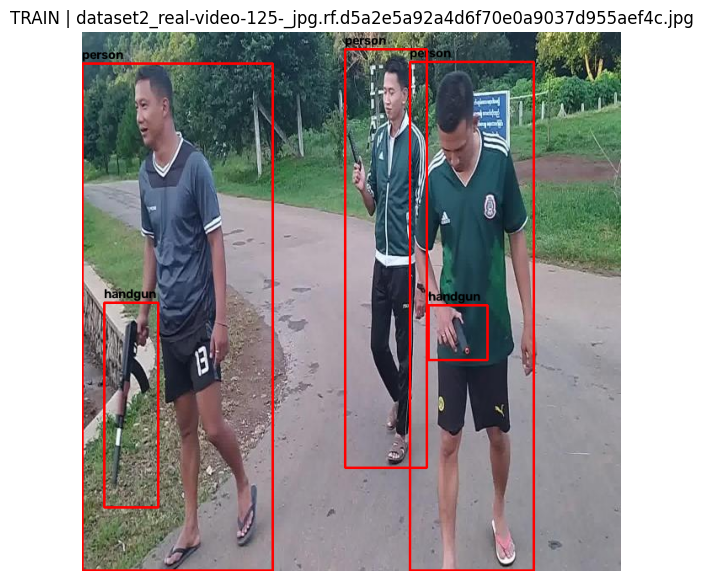

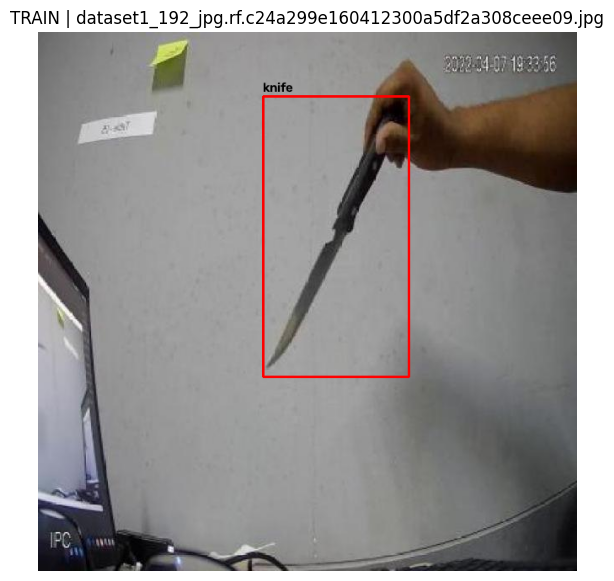

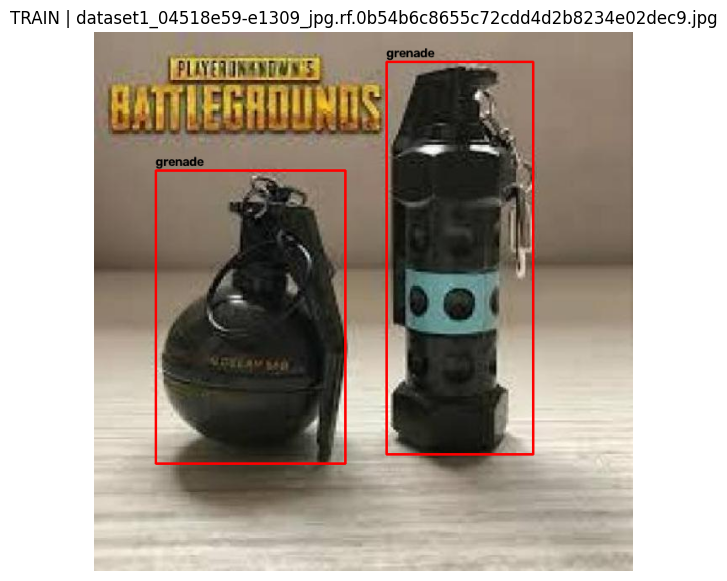


VALID VISUAL VERIFICATION


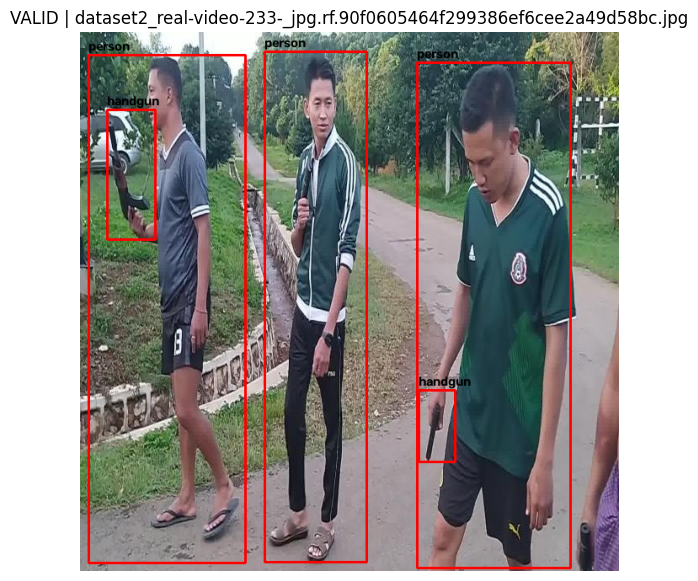

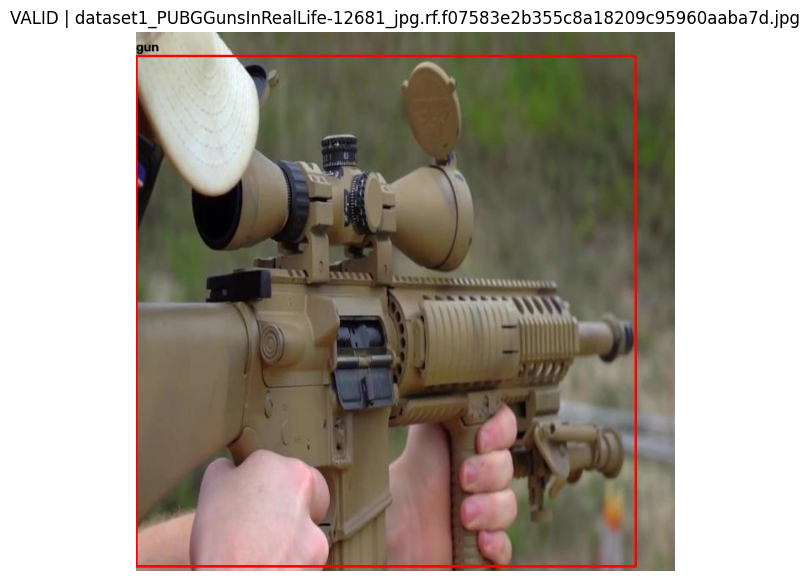

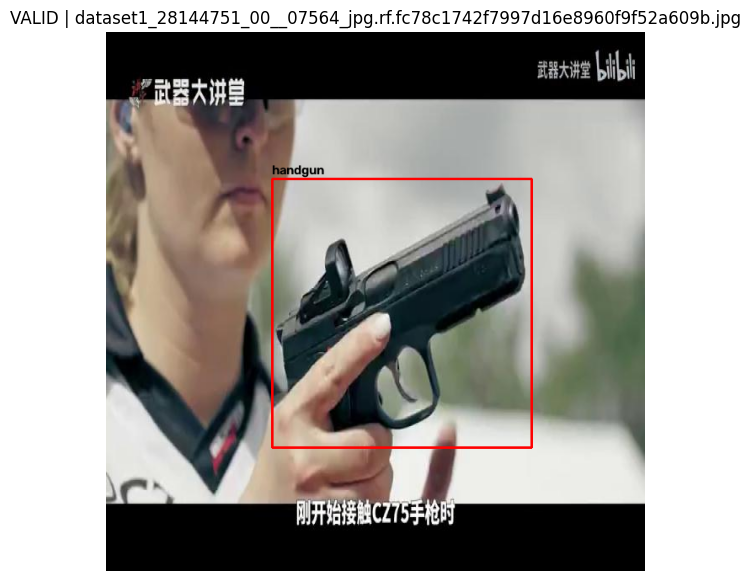


TEST VISUAL VERIFICATION


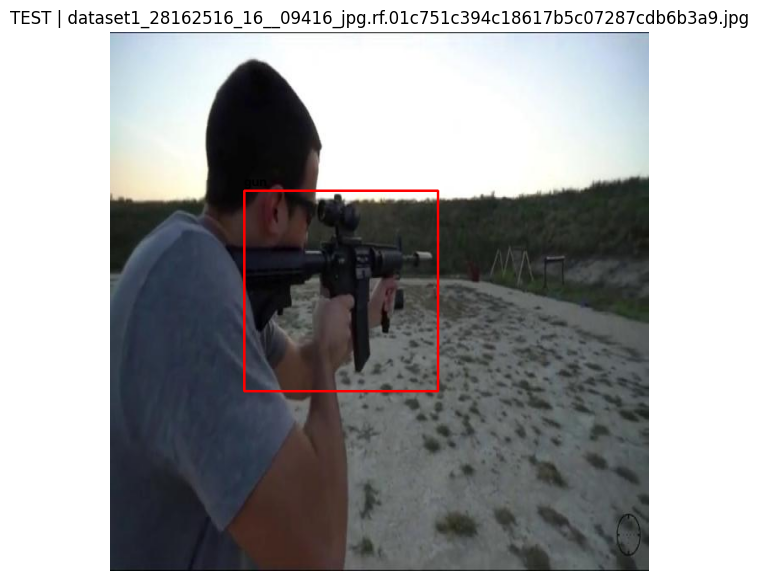

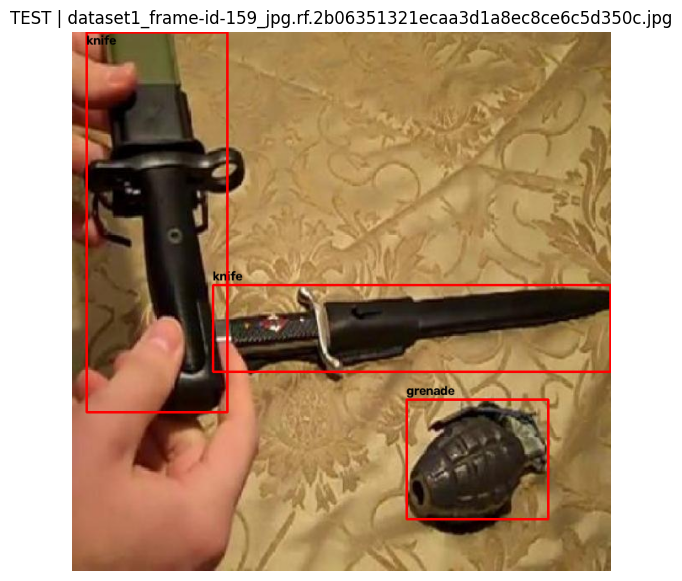

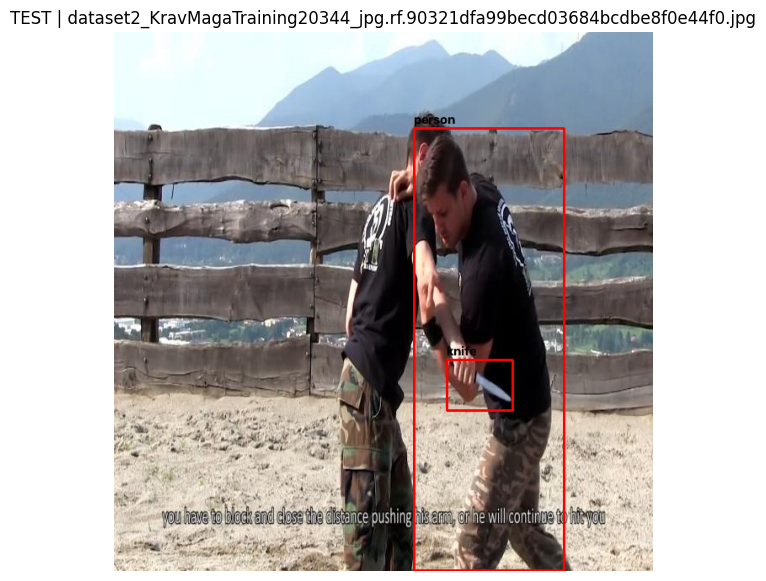

In [43]:
# ============================================================
# CELL 9: PRAHARI VISUAL GROUND-TRUTH VERIFICATION
# ============================================================

import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

CLASS_NAMES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun"
}

# Number of images to inspect from each split
SAMPLES_PER_SPLIT = 3

random.seed(42)

for split in ["train", "valid", "test"]:

    image_dir = MERGED_ROOT / split / "images"
    label_dir = MERGED_ROOT / split / "labels"

    image_files = [
        p for p in image_dir.iterdir()
        if p.is_file()
    ]

    selected_images = random.sample(
        image_files,
        min(SAMPLES_PER_SPLIT, len(image_files))
    )

    print("\n" + "=" * 70)
    print(f"{split.upper()} VISUAL VERIFICATION")
    print("=" * 70)

    for image_path in selected_images:

        label_path = label_dir / f"{image_path.stem}.txt"

        image = cv2.imread(str(image_path))

        if image is None:
            print(f"Could not read: {image_path.name}")
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        height, width = image.shape[:2]

        # ----------------------------------------------------
        # Read YOLO annotations
        # ----------------------------------------------------
        if label_path.exists():

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            for line in lines:

                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                class_id = int(float(parts[0]))

                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])

                # YOLO normalized -> pixel coordinates
                x1 = int(
                    (x_center - box_width / 2) * width
                )

                y1 = int(
                    (y_center - box_height / 2) * height
                )

                x2 = int(
                    (x_center + box_width / 2) * width
                )

                y2 = int(
                    (y_center + box_height / 2) * height
                )

                # Keep coordinates inside image
                x1 = max(0, min(width - 1, x1))
                y1 = max(0, min(height - 1, y1))
                x2 = max(0, min(width - 1, x2))
                y2 = max(0, min(height - 1, y2))

                class_name = CLASS_NAMES.get(
                    class_id,
                    f"class_{class_id}"
                )

                # Draw bounding box
                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2
                )

                # Draw label
                label = f"{class_name}"

                cv2.putText(
                    image,
                    label,
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 0, 0),
                    2
                )

        # ----------------------------------------------------
        # Display
        # ----------------------------------------------------
        plt.figure(figsize=(10, 7))
        plt.imshow(image)
        plt.title(
            f"{split.upper()} | {image_path.name}"
        )
        plt.axis("off")
        plt.show()

In [44]:
# ============================================================
# CELL 10: PRAHARI YOLO ENVIRONMENT CHECK
# ============================================================

# ============================================================
# CELL 10A: INSTALL ULTRALYTICS
# ============================================================

!pip install -q -U ultralytics
import torch
import ultralytics

print("=" * 70)
print("PRAHARI YOLO ENVIRONMENT CHECK")
print("=" * 70)

print(f"\nUltralytics version : {ultralytics.__version__}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():

    print(f"GPU count           : {torch.cuda.device_count()}")
    print(f"GPU name            : {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory          : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )

    print("\nSTATUS: GPU READY ✅")

else:

    print("\nSTATUS: GPU NOT AVAILABLE ❌")
    print("Go to Runtime -> Change runtime type -> T4 GPU")

print("\n" + "=" * 70)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.2 MB/s eta 0:00:00
PRAHARI YOLO ENVIRONMENT CHECK

Ultralytics version : 8.4.164
PyTorch version     : 2.11.0+cu128
CUDA available      : True
GPU count           : 1
GPU name            : Tesla T4
GPU memory          : 14.56 GB

STATUS: GPU READY ✅



In [46]:
# ============================================================
# CELL 11: VERIFY DATASET + LOAD YOLO11n
# ============================================================

from pathlib import Path
import yaml
from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_YAML = Path(
    "/content/drive/MyDrive/PRAHARI/merged/data.yaml"
)

# ------------------------------------------------------------
# Verify data.yaml exists
# ------------------------------------------------------------

print("=" * 70)
print("PRAHARI DATASET + YOLO11n CHECK")
print("=" * 70)

print(f"\nData YAML:")
print(DATA_YAML)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Dataset YAML not found: {DATA_YAML}"
    )

print("YAML exists: ✅")

# ------------------------------------------------------------
# Read YAML
# ------------------------------------------------------------

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("\nDataset configuration:")
print("-" * 70)

print(f"Path   : {data.get('path')}")
print(f"Train  : {data.get('train')}")
print(f"Val    : {data.get('val')}")
print(f"Test   : {data.get('test')}")
print(f"Classes: {data.get('nc')}")

# ------------------------------------------------------------
# Read class names
# ------------------------------------------------------------

names = data.get("names")

if names is None:
    raise ValueError(
        "No 'names' field found in data.yaml"
    )

print("\nClass names:")

# Support both list and dictionary formats
if isinstance(names, list):

    actual_classes = names

    for class_id, class_name in enumerate(names):
        print(
            f"  {class_id}: {class_name}"
        )

elif isinstance(names, dict):

    actual_classes = [
        names[key]
        for key in sorted(
            names.keys(),
            key=lambda x: int(x)
        )
    ]

    for class_id, class_name in enumerate(actual_classes):
        print(
            f"  {class_id}: {class_name}"
        )

else:

    raise TypeError(
        f"Unsupported 'names' format: "
        f"{type(names).__name__}"
    )


# ------------------------------------------------------------
# Verify expected 8-class taxonomy
# ------------------------------------------------------------

EXPECTED_CLASSES = [
    "person",
    "gun",
    "handgun",
    "rifle",
    "knife",
    "grenade",
    "shotgun",
    "submachine_gun"
]

# The 'actual_classes' variable is now correctly populated from the block above
if actual_classes != EXPECTED_CLASSES:
    raise ValueError(
        f"\nClass mismatch!\n"
        f"Expected: {EXPECTED_CLASSES}\n"
        f"Found:    {actual_classes}"
    )

if data["nc"] != 8:
    raise ValueError(
        f"Expected nc=8, found nc={data['nc']}"
    )

print("\nClass configuration: ✅ CORRECT")

# ------------------------------------------------------------
# Load YOLO11n
# ------------------------------------------------------------

print("\nLoading YOLO11n pretrained model...")

model = YOLO("yolo11n.pt")

print("\nYOLO11n loaded successfully! ✅")

print("=" * 70)
print("READY FOR BASELINE TRAINING")
print("=" * 70)

PRAHARI DATASET + YOLO11n CHECK

Data YAML:
/content/drive/MyDrive/PRAHARI/merged/data.yaml
YAML exists: ✅

Dataset configuration:
----------------------------------------------------------------------
Path   : /content/drive/MyDrive/PRAHARI/merged
Train  : train/images
Val    : valid/images
Test   : test/images
Classes: 8

Class names:
  0: person
  1: gun
  2: handgun
  3: rifle
  4: knife
  5: grenade
  6: shotgun
  7: submachine_gun

Class configuration: ✅ CORRECT

Loading YOLO11n pretrained model...

YOLO11n loaded successfully! ✅
READY FOR BASELINE TRAINING


In [47]:
# ============================================================
# CELL 11: VERIFY DATASET + LOAD YOLO11n
# ============================================================

from pathlib import Path
import yaml
from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_YAML = Path(
    "/content/drive/MyDrive/PRAHARI/merged/data.yaml"
)

# ------------------------------------------------------------
# Verify data.yaml exists
# ------------------------------------------------------------

print("=" * 70)
print("PRAHARI DATASET + YOLO11n CHECK")
print("=" * 70)

print("\nData YAML:")
print(DATA_YAML)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Dataset YAML not found: {DATA_YAML}"
    )

print("YAML exists: ✅")


# ------------------------------------------------------------
# Read YAML
# ------------------------------------------------------------

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)


print("\nDataset configuration:")
print("-" * 70)

print(f"Path   : {data.get('path')}")
print(f"Train  : {data.get('train')}")
print(f"Val    : {data.get('val')}")
print(f"Test   : {data.get('test')}")
print(f"Classes: {data.get('nc')}")


# ------------------------------------------------------------
# Read class names
# ------------------------------------------------------------

names = data.get("names")

if names is None:
    raise ValueError(
        "No 'names' field found in data.yaml"
    )


print("\nClass names:")

# Support both list and dictionary formats
if isinstance(names, list):

    actual_classes = names

    for class_id, class_name in enumerate(names):
        print(
            f"  {class_id}: {class_name}"
        )

elif isinstance(names, dict):

    actual_classes = [
        names[key]
        for key in sorted(
            names.keys(),
            key=lambda x: int(x)
        )
    ]

    for class_id, class_name in enumerate(actual_classes):
        print(
            f"  {class_id}: {class_name}"
        )

else:

    raise TypeError(
        f"Unsupported 'names' format: "
        f"{type(names).__name__}"
    )


# ------------------------------------------------------------
# Expected PRAHARI taxonomy
# ------------------------------------------------------------

EXPECTED_CLASSES = [
    "person",
    "gun",
    "handgun",
    "rifle",
    "knife",
    "grenade",
    "shotgun",
    "submachine_gun"
]


# ------------------------------------------------------------
# Verify class taxonomy
# ------------------------------------------------------------

if actual_classes != EXPECTED_CLASSES:

    raise ValueError(
        "\nClass mismatch!\n"
        f"Expected: {EXPECTED_CLASSES}\n"
        f"Found:    {actual_classes}"
    )


if data.get("nc") != len(EXPECTED_CLASSES):

    raise ValueError(
        f"Expected nc={len(EXPECTED_CLASSES)}, "
        f"found nc={data.get('nc')}"
    )


print("\nClass configuration: ✅ CORRECT")


# ------------------------------------------------------------
# Verify dataset directories
# ------------------------------------------------------------

DATASET_ROOT = Path(data["path"])

if not DATASET_ROOT.exists():

    raise FileNotFoundError(
        f"Dataset root not found:\n{DATASET_ROOT}"
    )


print("\nDataset root: ✅")


for split, relative_path in {
    "TRAIN": data["train"],
    "VALID": data["val"],
    "TEST": data["test"]
}.items():

    split_path = DATASET_ROOT / relative_path

    print(
        f"{split:5s} images: "
        f"{split_path}"
    )

    if not split_path.exists():

        raise FileNotFoundError(
            f"{split} directory not found:\n"
            f"{split_path}"
        )

    print("       Status: ✅")


# ------------------------------------------------------------
# Load YOLO11n pretrained model
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LOADING YOLO11n PRETRAINED MODEL")
print("=" * 70)

model = YOLO("yolo11n.pt")

print("\nYOLO11n loaded successfully! ✅")


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("READY FOR BASELINE TRAINING")
print("=" * 70)

print("\nDataset:")
print(DATA_YAML)

print("\nClasses:")
for i, name in enumerate(actual_classes):
    print(f"  {i}: {name}")

print("\nModel: YOLO11n")
print("Status: ✅ READY")

PRAHARI DATASET + YOLO11n CHECK

Data YAML:
/content/drive/MyDrive/PRAHARI/merged/data.yaml
YAML exists: ✅

Dataset configuration:
----------------------------------------------------------------------
Path   : /content/drive/MyDrive/PRAHARI/merged
Train  : train/images
Val    : valid/images
Test   : test/images
Classes: 8

Class names:
  0: person
  1: gun
  2: handgun
  3: rifle
  4: knife
  5: grenade
  6: shotgun
  7: submachine_gun

Class configuration: ✅ CORRECT

Dataset root: ✅
TRAIN images: /content/drive/MyDrive/PRAHARI/merged/train/images
       Status: ✅
VALID images: /content/drive/MyDrive/PRAHARI/merged/valid/images
       Status: ✅
TEST  images: /content/drive/MyDrive/PRAHARI/merged/test/images
       Status: ✅

LOADING YOLO11n PRETRAINED MODEL

YOLO11n loaded successfully! ✅

READY FOR BASELINE TRAINING

Dataset:
/content/drive/MyDrive/PRAHARI/merged/data.yaml

Classes:
  0: person
  1: gun
  2: handgun
  3: rifle
  4: knife
  5: grenade
  6: shotgun
  7: submachine_gun


In [48]:
# ============================================================
# CELL 12: PRAHARI YOLO11n BASELINE TRAINING
# ============================================================

!pip install -q -U ultralytics
from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_YAML = "/content/drive/MyDrive/PRAHARI/merged/data.yaml"

RUNS_DIR = "/content/drive/MyDrive/PRAHARI/runs"

# ------------------------------------------------------------
# Load pretrained YOLO11n
# ------------------------------------------------------------

model = YOLO("yolo11n.pt")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

results = model.train(
    data=DATA_YAML,

    epochs=25.,
    imgsz=640,
    batch=16,

    device=0,
    workers=2,

    pretrained=True,

    patience=10,

    project=RUNS_DIR,
    name="yolo11n_baseline",

    save=True,
    plots=True,

    verbose=True
)

print("\n" + "=" * 70)
print("PRAHARI YOLO11n BASELINE TRAINING COMPLETE")
print("=" * 70)

print("\nResults saved to:")
print(f"{RUNS_DIR}/yolo11n_baseline")

print("\nBest model:")
print(f"{RUNS_DIR}/yolo11n_baseline/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.165 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PRAHARI/merged/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=y

In [49]:
# ============================================================
# CELL 13: PRAHARI BASELINE METRICS
# ============================================================

from pathlib import Path
import pandas as pd

RUN_DIR = Path(
    "/content/drive/MyDrive/PRAHARI/runs/yolo11n_baseline"
)

RESULTS_CSV = RUN_DIR / "results.csv"
BEST_MODEL = RUN_DIR / "weights/best.pt"
LAST_MODEL = RUN_DIR / "weights/last.pt"

print("=" * 70)
print("PRAHARI YOLO11n BASELINE RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

print("\nRun directory:")
print(RUN_DIR)

print(f"\nresults.csv : {RESULTS_CSV.exists()}")
print(f"best.pt     : {BEST_MODEL.exists()}")
print(f"last.pt     : {LAST_MODEL.exists()}")

if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        f"results.csv not found at:\n{RESULTS_CSV}"
    )

# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------

df = pd.read_csv(RESULTS_CSV)

# Remove accidental whitespace from column names
df.columns = df.columns.str.strip()

print("\nAvailable metric columns:")
for col in df.columns:
    print(f"  {col}")

# ------------------------------------------------------------
# Show final epoch
# ------------------------------------------------------------

final_epoch = df.iloc[-1]

print("\n" + "=" * 70)
print("FINAL EPOCH METRICS")
print("=" * 70)

for col in df.columns:
    if col != "epoch":
        value = final_epoch[col]

        if pd.notna(value):
            try:
                print(f"{col:<45} {float(value):.4f}")
            except:
                print(f"{col:<45} {value}")

# ------------------------------------------------------------
# Find best epoch using validation mAP50-95
# ------------------------------------------------------------

map95_candidates = [
    col for col in df.columns
    if "mAP50-95" in col
]

if map95_candidates:

    map95_col = map95_candidates[0]

    best_idx = df[map95_col].idxmax()
    best_row = df.loc[best_idx]

    print("\n" + "=" * 70)
    print("BEST EPOCH BY VALIDATION mAP50-95")
    print("=" * 70)

    print(f"\nEpoch: {int(best_row['epoch'])}")

    for col in df.columns:
        if col == "epoch":
            continue

        value = best_row[col]

        if pd.notna(value):
            try:
                print(f"{col:<45} {float(value):.4f}")
            except:
                print(f"{col:<45} {value}")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PRAHARI BASELINE METRICS EXTRACTED ✅")
print("=" * 70)

PRAHARI YOLO11n BASELINE RESULTS

Run directory:
/content/drive/MyDrive/PRAHARI/runs/yolo11n_baseline

results.csv : True
best.pt     : True
last.pt     : True

Available metric columns:
  epoch
  time
  train/box_loss
  train/cls_loss
  train/dfl_loss
  metrics/precision(B)
  metrics/recall(B)
  metrics/mAP50(B)
  metrics/mAP50-95(B)
  val/box_loss
  val/cls_loss
  val/dfl_loss
  lr/pg0
  lr/pg1
  lr/pg2

FINAL EPOCH METRICS
time                                          7326.9100
train/box_loss                                0.8539
train/cls_loss                                0.6696
train/dfl_loss                                1.1544
metrics/precision(B)                          0.8155
metrics/recall(B)                             0.6792
metrics/mAP50(B)                              0.7576
metrics/mAP50-95(B)                           0.5428
val/box_loss                                  1.0517
val/cls_loss                                  0.8430
val/dfl_loss                         

In [50]:
# ============================================================
# CELL 14: IDENTIFY BASELINE DATASET
# ============================================================

from pathlib import Path
import yaml

# Change this if your actual YAML path is different
DATA_YAML = Path(
    "/content/drive/MyDrive/PRAHARI/merged/data.yaml"
)

print("=" * 70)
print("PRAHARI BASELINE DATASET VERIFICATION")
print("=" * 70)

print("\nDataset YAML:")
print(DATA_YAML)

print("Exists:", DATA_YAML.exists())

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Dataset YAML not found:\n{DATA_YAML}"
    )

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("\n" + "=" * 70)
print("DATASET CONFIGURATION")
print("=" * 70)

for key, value in data.items():
    print(f"{key}: {value}")

print("\n" + "=" * 70)
print("CLASS DEFINITIONS")
print("=" * 70)

names = data.get("names", {})

if isinstance(names, dict):
    for class_id, class_name in names.items():
        print(f"{class_id}: {class_name}")
else:
    for class_id, class_name in enumerate(names):
        print(f"{class_id}: {class_name}")

PRAHARI BASELINE DATASET VERIFICATION

Dataset YAML:
/content/drive/MyDrive/PRAHARI/merged/data.yaml
Exists: True

DATASET CONFIGURATION
path: /content/drive/MyDrive/PRAHARI/merged
train: train/images
val: valid/images
test: test/images
nc: 8
names: ['person', 'gun', 'handgun', 'rifle', 'knife', 'grenade', 'shotgun', 'submachine_gun']

CLASS DEFINITIONS
0: person
1: gun
2: handgun
3: rifle
4: knife
5: grenade
6: shotgun
7: submachine_gun


In [51]:
# ============================================================
# CELL 14: PRAHARI YOLO11n TEST SET EVALUATION
# ============================================================

from ultralytics import YOLO
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_YAML = "/content/drive/MyDrive/PRAHARI/merged/data.yaml"

BEST_MODEL = (
    "/content/drive/MyDrive/PRAHARI/"
    "runs/yolo11n_baseline/weights/best.pt"
)

TEST_RUN_DIR = (
    "/content/drive/MyDrive/PRAHARI/"
    "runs/yolo11n_test"
)

# ------------------------------------------------------------
# Load best model
# ------------------------------------------------------------

print("=" * 70)
print("PRAHARI YOLO11n TEST SET EVALUATION")
print("=" * 70)

print("\nLoading best model:")
print(BEST_MODEL)

model = YOLO(BEST_MODEL)

print("\nModel loaded successfully ✅")

# ------------------------------------------------------------
# Evaluate on TEST split
# ------------------------------------------------------------

print("\nRunning evaluation on HELD-OUT TEST SET...")
print("This may take several minutes.\n")

metrics = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="/content/drive/MyDrive/PRAHARI/runs",
    name="yolo11n_test",
    plots=True,
    save_json=True
)

# ------------------------------------------------------------
# Print overall metrics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PRAHARI TEST SET RESULTS")
print("=" * 70)

print(f"\nPrecision      : {metrics.box.mp:.4f}")
print(f"Recall         : {metrics.box.mr:.4f}")
print(f"mAP@50         : {metrics.box.map50:.4f}")
print(f"mAP@50:95      : {metrics.box.map:.4f}")

print("\nPercentage form:")

print(f"Precision      : {metrics.box.mp * 100:.2f}%")
print(f"Recall         : {metrics.box.mr * 100:.2f}%")
print(f"mAP@50         : {metrics.box.map50 * 100:.2f}%")
print(f"mAP@50:95      : {metrics.box.map * 100:.2f}%")

# ------------------------------------------------------------
# Per-class metrics
# ------------------------------------------------------------

CLASS_NAMES = [
    "person",
    "gun",
    "handgun",
    "rifle",
    "knife",
    "grenade",
    "shotgun",
    "submachine_gun"
]

print("\n" + "=" * 70)
print("PER-CLASS TEST METRICS")
print("=" * 70)

for i, class_name in enumerate(CLASS_NAMES):

    try:
        print(
            f"{class_name:<18} "
            f"P={metrics.box.p[i]:.4f}  "
            f"R={metrics.box.r[i]:.4f}  "
            f"mAP50={metrics.box.ap50[i]:.4f}  "
            f"mAP50-95={metrics.box.ap[i]:.4f}"
        )

    except Exception:
        print(f"{class_name:<18} metrics unavailable")

print("\n" + "=" * 70)
print("TEST EVALUATION COMPLETE ✅")
print("=" * 70)

print("\nResults saved to:")
print(TEST_RUN_DIR)

PRAHARI YOLO11n TEST SET EVALUATION

Loading best model:
/content/drive/MyDrive/PRAHARI/runs/yolo11n_baseline/weights/best.pt

Model loaded successfully ✅

Running evaluation on HELD-OUT TEST SET...
This may take several minutes.

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,583,712 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.1 ms, read: 16.1±8.2 MB/s, size: 51.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/PRAHARI/merged/test/labels... 1835 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1835/1835 179.9it/s 10.2s
val: New cache created: /content/drive/MyDrive/PRAHARI/merged/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 115/115 4.8it/s 24.1s
       

# ***Phase 3***

In [52]:
# ============================================================
# CELL 15: PRAHARI THREAT ASSESSMENT MODULE
# ============================================================

from pathlib import Path
import json

# ------------------------------------------------------------
# Threat taxonomy
# ------------------------------------------------------------

THREAT_RULES = {

    "person": {
        "category": "contextual_object",
        "severity": "informational"
    },

    "gun": {
        "category": "weapon_threat",
        "severity": "high"
    },

    "handgun": {
        "category": "weapon_threat",
        "severity": "high"
    },

    "rifle": {
        "category": "weapon_threat",
        "severity": "high"
    },

    "knife": {
        "category": "edged_weapon_threat",
        "severity": "high"
    },

    "grenade": {
        "category": "explosive_threat",
        "severity": "critical"
    },

    "shotgun": {
        "category": "weapon_threat",
        "severity": "high"
    },

    "submachine_gun": {
        "category": "weapon_threat",
        "severity": "high"
    }
}

# ------------------------------------------------------------
# Detection assessment function
# ------------------------------------------------------------

def assess_threat(class_name, confidence):

    class_name = class_name.lower().strip()

    if class_name not in THREAT_RULES:
        return {
            "class": class_name,
            "confidence": float(confidence),
            "category": "unknown",
            "severity": "unknown",
            "alert": False
        }

    rule = THREAT_RULES[class_name]

    # Minimum confidence for an operator-facing alert
    alert = (
        class_name != "person"
        and float(confidence) >= 0.50
    )

    return {
        "class": class_name,
        "confidence": round(float(confidence), 4),
        "category": rule["category"],
        "severity": rule["severity"],
        "alert": alert
    }


# ------------------------------------------------------------
# Demonstration
# ------------------------------------------------------------

print("=" * 70)
print("PRAHARI THREAT ASSESSMENT")
print("=" * 70)

test_detections = [
    ("handgun", 0.91),
    ("grenade", 0.87),
    ("knife", 0.82),
    ("person", 0.94),
    ("rifle", 0.76)
]

for class_name, confidence in test_detections:

    result = assess_threat(
        class_name,
        confidence
    )

    print("\nDetection")
    print("-" * 70)

    print(f"Class      : {result['class']}")
    print(f"Confidence : {result['confidence'] * 100:.2f}%")
    print(f"Category   : {result['category']}")
    print(f"Severity   : {result['severity']}")
    print(f"Alert      : {result['alert']}")

print("\n" + "=" * 70)
print("THREAT ASSESSMENT MODULE READY ✅")
print("=" * 70)

PRAHARI THREAT ASSESSMENT

Detection
----------------------------------------------------------------------
Class      : handgun
Confidence : 91.00%
Category   : weapon_threat
Severity   : high
Alert      : True

Detection
----------------------------------------------------------------------
Class      : grenade
Confidence : 87.00%
Category   : explosive_threat
Severity   : critical
Alert      : True

Detection
----------------------------------------------------------------------
Class      : knife
Confidence : 82.00%
Category   : edged_weapon_threat
Severity   : high
Alert      : True

Detection
----------------------------------------------------------------------
Class      : person
Confidence : 94.00%
Category   : contextual_object
Severity   : informational
Alert      : False

Detection
----------------------------------------------------------------------
Class      : rifle
Confidence : 76.00%
Category   : weapon_threat
Severity   : high
Alert      : True

THREAT ASSESSMENT MOD

In [53]:
# ============================================================
# CELL 16: PRAHARI YOLO11n → THREAT ASSESSMENT
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import json
import random

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BEST_MODEL = Path(
    "/content/drive/MyDrive/PRAHARI/"
    "runs/yolo11n_baseline/weights/best.pt"
)

TEST_IMAGES = Path(
    "/content/drive/MyDrive/PRAHARI/"
    "merged/test/images"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/PRAHARI/"
    "runs/threat_assessment"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_FILE = OUTPUT_DIR / "threat_assessment_report.json"

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------

print("=" * 70)
print("PRAHARI YOLO11n → THREAT ASSESSMENT")
print("=" * 70)

print("\nLoading trained model...")

model = YOLO(str(BEST_MODEL))

print("Model loaded: ✅")

# ------------------------------------------------------------
# Threat rules
# ------------------------------------------------------------

THREAT_RULES = {

    "person": {
        "category": "contextual_object",
        "severity": "informational"
    },

    "gun": {
        "category": "weapon_threat",
        "severity": "high"
    },

    "handgun": {
        "category": "weapon_threat",
        "severity": "high"
    },

    "rifle": {
        "category": "weapon_threat",
        "severity": "high"
    },

    "knife": {
        "category": "edged_weapon_threat",
        "severity": "high"
    },

    "grenade": {
        "category": "explosive_threat",
        "severity": "critical"
    },

    "shotgun": {
        "category": "weapon_threat",
        "severity": "high"
    },

    "submachine_gun": {
        "category": "weapon_threat",
        "severity": "high"
    }
}

# ------------------------------------------------------------
# Collect test images
# ------------------------------------------------------------

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

test_images = [
    p for p in TEST_IMAGES.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]

if not test_images:
    raise RuntimeError(
        f"No test images found in {TEST_IMAGES}"
    )

# ------------------------------------------------------------
# Select sample images
# ------------------------------------------------------------

random.seed(42)

SAMPLE_COUNT = min(20, len(test_images))

sample_images = random.sample(
    test_images,
    SAMPLE_COUNT
)

print(f"\nTest images available : {len(test_images)}")
print(f"Images selected       : {SAMPLE_COUNT}")

# ------------------------------------------------------------
# Run detection
# ------------------------------------------------------------

report = []

print("\nRunning PRAHARI detection...\n")

for image_path in sample_images:

    results = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )

    result = results[0]

    # Save annotated prediction image
    annotated = result.plot(
        labels=True,
        conf=True,
        boxes=True
    )

    output_image = OUTPUT_DIR / image_path.name

    # Save using OpenCV
    import cv2

    cv2.imwrite(
        str(output_image),
        annotated
    )

    image_report = {
        "image": image_path.name,
        "detections": []
    }

    # --------------------------------------------------------
    # Process detections
    # --------------------------------------------------------

    if result.boxes is not None:

        for box in result.boxes:

            class_id = int(
                box.cls[0].item()
            )

            confidence = float(
                box.conf[0].item()
            )

            class_name = model.names[class_id]

            rule = THREAT_RULES.get(
                class_name,
                {
                    "category": "unknown",
                    "severity": "unknown"
                }
            )

            alert = (
                class_name != "person"
                and confidence >= 0.50
            )

            detection = {
                "class": class_name,
                "confidence": round(
                    confidence,
                    4
                ),
                "category": rule["category"],
                "severity": rule["severity"],
                "alert": alert,
                "bbox": [
                    round(float(x), 2)
                    for x in box.xyxy[0].tolist()
                ]
            }

            image_report["detections"].append(
                detection
            )

            print(
                f"{image_path.name:<35} "
                f"{class_name:<18} "
                f"{confidence * 100:6.2f}% "
                f"{rule['severity']:<12} "
                f"Alert={alert}"
            )

    report.append(image_report)

# ------------------------------------------------------------
# Save JSON report
# ------------------------------------------------------------

with open(
    REPORT_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

total_detections = sum(
    len(item["detections"])
    for item in report
)

total_alerts = sum(
    sum(
        detection["alert"]
        for detection in item["detections"]
    )
    for item in report
)

print("\n" + "=" * 70)
print("THREAT ASSESSMENT COMPLETE ✅")
print("=" * 70)

print(f"\nImages processed    : {SAMPLE_COUNT}")
print(f"Total detections    : {total_detections}")
print(f"Operator alerts     : {total_alerts}")

print("\nPrediction images:")
print(OUTPUT_DIR)

print("\nJSON report:")
print(REPORT_FILE)

print("\n" + "=" * 70)

PRAHARI YOLO11n → THREAT ASSESSMENT

Loading trained model...
Model loaded: ✅

Test images available : 1835
Images selected       : 20

Running PRAHARI detection...

dataset2_CMK56RIE83JW_jpg.rf.d65c1386974da5be443a62915b8837a4.jpg rifle               91.76% high         Alert=True
dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg gun                 95.22% high         Alert=True
dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg gun                 93.95% high         Alert=True
dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg gun                 93.62% high         Alert=True
dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg gun                 91.81% high         Alert=True
dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg gun                 88.58% high         Alert=True
dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e3

PRAHARI YOLO11n → EXPLAINABLE AI

Loading trained model...
Model loaded: ✅

Test images available : 1835
Images selected       : 6

Generating XAI visualizations...



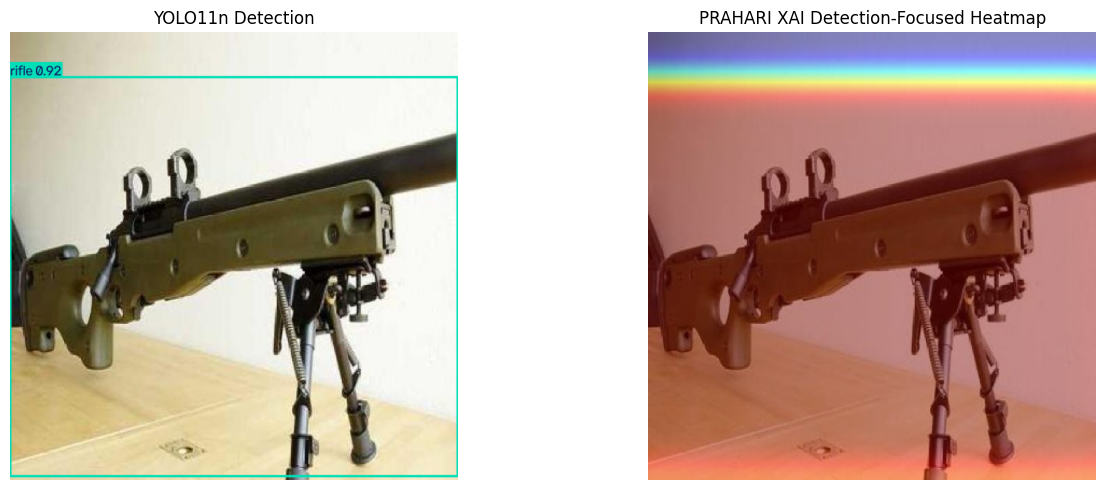

Image      : dataset2_CMK56RIE83JW_jpg.rf.d65c1386974da5be443a62915b8837a4.jpg
Detections : 1
  rifle               91.76%


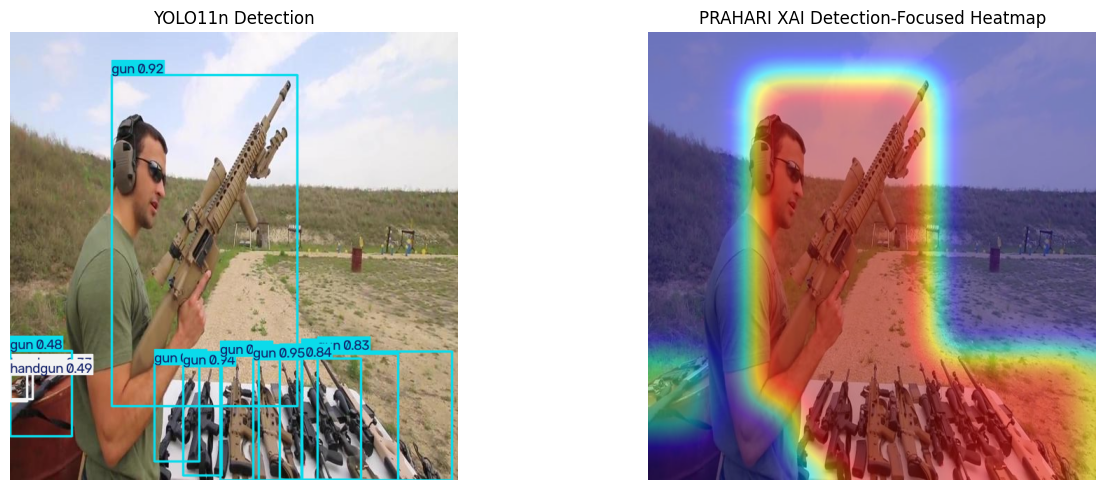

Image      : dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg
Detections : 11
  gun                 95.22%
  gun                 93.95%
  gun                 93.62%
  gun                 91.81%
  gun                 88.58%
  gun                 84.47%
  gun                 83.15%
  gun                 59.94%
  handgun             48.94%
  gun                 47.87%
  handgun             32.57%


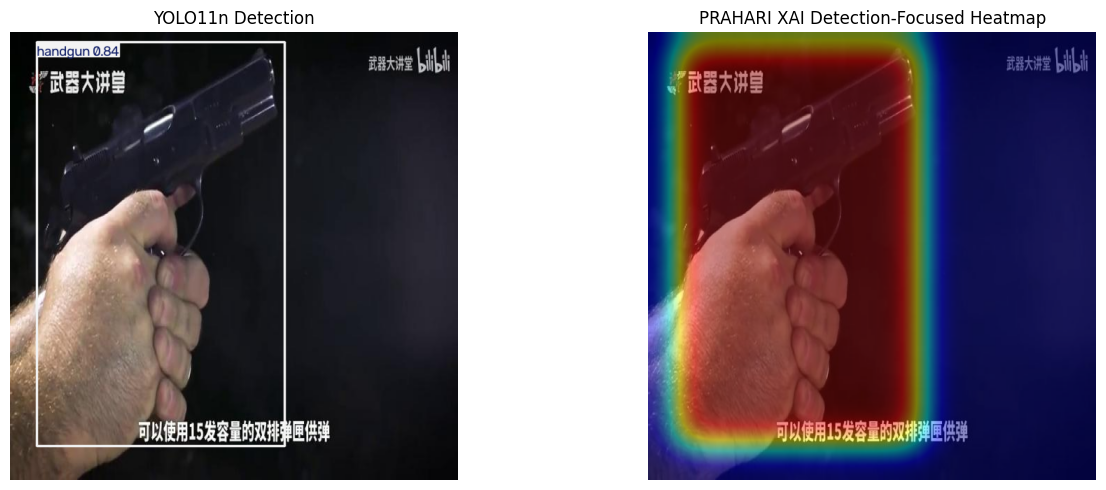

Image      : dataset1_2814478_00__05480_jpg.rf.d314cc6374c9aa74f7b30645986d338d.jpg
Detections : 1
  handgun             84.23%


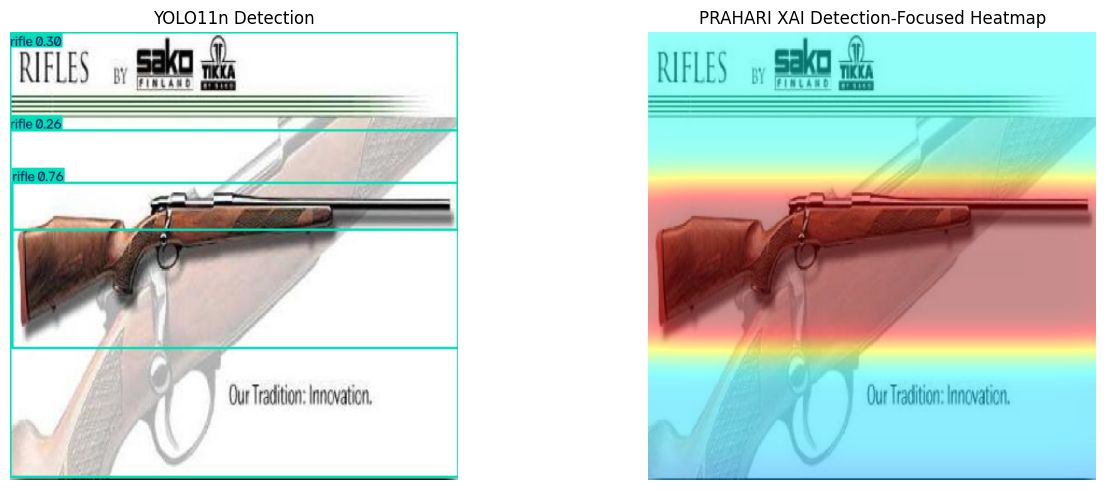

Image      : dataset2_XN7GE4ESYGDQ_jpg.rf.7b0648b39542b837ed8982c462b16339.jpg
Detections : 3
  rifle               75.82%
  rifle               29.65%
  rifle               25.80%


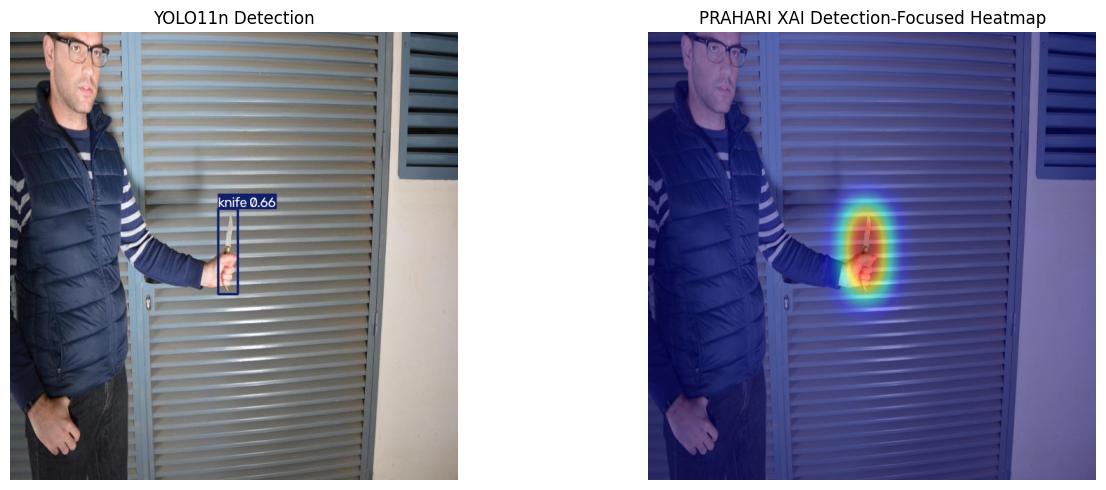

Image      : dataset1_DSC_00211_jpg.rf.5b37d18d1f9c412d9dfaaf6240d2a368.jpg
Detections : 1
  knife               65.66%


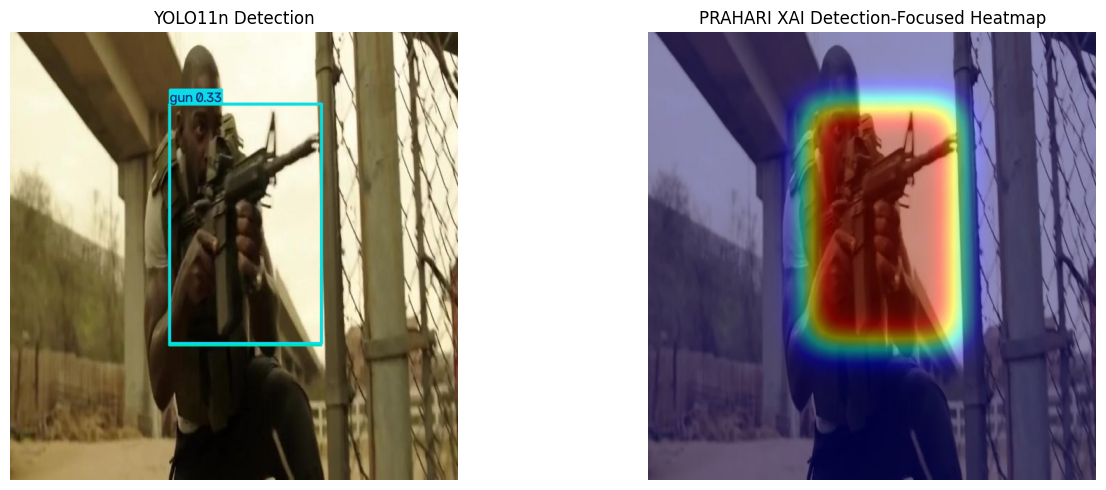

Image      : dataset1_den-of-thieves2018-final-gun-fight-with-police-movie-cube03541_jpg.rf.c704ec4674ba324e7aad86039c33dd98.jpg
Detections : 2
  gun                 33.01%
  rifle               26.31%

XAI GENERATION COMPLETE ✅

XAI results saved to:
/content/drive/MyDrive/PRAHARI/runs/xai


In [54]:
# ============================================================
# CELL 17: PRAHARI XAI VISUALIZATION
# ============================================================

from pathlib import Path
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MODEL_PATH = Path(
    "/content/drive/MyDrive/PRAHARI/runs/yolo11n_baseline/weights/best.pt"
)

TEST_IMAGE_DIR = Path(
    "/content/drive/MyDrive/PRAHARI/merged/test/images"
)

XAI_DIR = Path(
    "/content/drive/MyDrive/PRAHARI/runs/xai"
)

XAI_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------

print("=" * 70)
print("PRAHARI YOLO11n → EXPLAINABLE AI")
print("=" * 70)

print("\nLoading trained model...")
model = YOLO(str(MODEL_PATH))
print("Model loaded: ✅")

# ------------------------------------------------------------
# Select images
# ------------------------------------------------------------

image_paths = list(TEST_IMAGE_DIR.glob("*"))

random.seed(42)
selected_images = random.sample(
    image_paths,
    min(6, len(image_paths))
)

print(f"\nTest images available : {len(image_paths)}")
print(f"Images selected       : {len(selected_images)}")

# ------------------------------------------------------------
# Run detection
# ------------------------------------------------------------

print("\nGenerating XAI visualizations...\n")

class_names = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun"
}

for image_path in selected_images:

    # Read image
    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Skipping unreadable image: {image_path.name}")
        continue

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # YOLO prediction
    results = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )

    result = results[0]

    # --------------------------------------------------------
    # Create detection visualization
    # --------------------------------------------------------

    annotated = result.plot(
        labels=True,
        conf=True,
        boxes=True
    )

    annotated_rgb = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # Create simple detection-focused XAI map
    # --------------------------------------------------------

    xai_map = np.zeros(
        image_rgb.shape[:2],
        dtype=np.float32
    )

    detections = []

    if result.boxes is not None:

        boxes = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy().astype(int)

        for box, conf, cls_id in zip(boxes, confs, classes):

            x1, y1, x2, y2 = box.astype(int)

            x1 = max(0, min(x1, image_rgb.shape[1] - 1))
            x2 = max(0, min(x2, image_rgb.shape[1] - 1))
            y1 = max(0, min(y1, image_rgb.shape[0] - 1))
            y2 = max(0, min(y2, image_rgb.shape[0] - 1))

            if x2 <= x1 or y2 <= y1:
                continue

            # Confidence-weighted detection region
            xai_map[y1:y2, x1:x2] = np.maximum(
                xai_map[y1:y2, x1:x2],
                conf
            )

            detections.append({
                "class": class_names.get(cls_id, str(cls_id)),
                "confidence": float(conf),
                "bbox": [
                    int(x1),
                    int(y1),
                    int(x2),
                    int(y2)
                ]
            })

    # --------------------------------------------------------
    # Smooth the detection regions
    # --------------------------------------------------------

    xai_blur = cv2.GaussianBlur(
        xai_map,
        (0, 0),
        sigmaX=25
    )

    # Normalize
    if xai_blur.max() > 0:
        xai_blur = xai_blur / xai_blur.max()

    # --------------------------------------------------------
    # Convert to heatmap
    # --------------------------------------------------------

    heatmap = cv2.applyColorMap(
        np.uint8(255 * xai_blur),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    # Make background less dominant
    heatmap_overlay = cv2.addWeighted(
        image_rgb,
        0.55,
        heatmap,
        0.45,
        0
    )

    # --------------------------------------------------------
    # Save images
    # --------------------------------------------------------

    stem = image_path.stem

    detection_path = XAI_DIR / f"{stem}_detection.jpg"
    heatmap_path = XAI_DIR / f"{stem}_xai.jpg"

    cv2.imwrite(
        str(detection_path),
        cv2.cvtColor(annotated_rgb, cv2.COLOR_RGB2BGR)
    )

    cv2.imwrite(
        str(heatmap_path),
        cv2.cvtColor(heatmap_overlay, cv2.COLOR_RGB2BGR)
    )

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(annotated_rgb)
    plt.title("YOLO11n Detection")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_overlay)
    plt.title("PRAHARI XAI Detection-Focused Heatmap")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Image      : {image_path.name}")
    print(f"Detections : {len(detections)}")

    for det in detections:
        print(
            f"  {det['class']:18s} "
            f"{det['confidence'] * 100:6.2f}%"
        )

print("\n" + "=" * 70)
print("XAI GENERATION COMPLETE ✅")
print("=" * 70)

print(f"\nXAI results saved to:")
print(XAI_DIR)

In [57]:
# ============================================================
# CELL 18: PRAHARI VOICE ALERT SYSTEM
# ============================================================

from pathlib import Path
import json
import random
import subprocess
import sys
import os

from ultralytics import YOLO

# ------------------------------------------------------------
# Install text-to-speech package
# ------------------------------------------------------------

print("=" * 70)
print("PRAHARI YOLO11n → VOICE ALERT SYSTEM")
print("=" * 70)

print("\nInstalling text-to-speech dependency...")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "pyttsx3"],
    check=True
)

# Install eSpeak for pyttsx3
print("Installing eSpeak system package...")
subprocess.run(["apt-get", "update"], check=True, capture_output=True)
subprocess.run(["apt-get", "install", "-y", "espeak"], check=True, capture_output=True)
print("eSpeak installed: ✅")

import pyttsx3

print("Text-to-speech package: ✅")

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MODEL_PATH = Path(
    "/content/drive/MyDrive/PRAHARI/runs/yolo11n_baseline/weights/best.pt"
)

TEST_IMAGE_DIR = Path(
    "/content/drive/MyDrive/PRAHARI/merged/test/images"
)

VOICE_DIR = Path(
    "/content/drive/MyDrive/PRAHARI/runs/voice_alert"
)

VOICE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Threat assessment rules
# ------------------------------------------------------------

THREAT_RULES = {
    "person": {
        "category": "contextual_object",
        "severity": "informational",
        "alert": False
    },

    "gun": {
        "category": "weapon_threat",
        "severity": "high",
        "alert": True
    },

    "handgun": {
        "category": "weapon_threat",
        "severity": "high",
        "alert": True
    },

    "rifle": {
        "category": "weapon_threat",
        "severity": "high",
        "alert": True
    },

    "knife": {
        "category": "edged_weapon_threat",
        "severity": "high",
        "alert": True
    },

    "grenade": {
        "category": "explosive_threat",
        "severity": "critical",
        "alert": True
    },

    "shotgun": {
        "category": "weapon_threat",
        "severity": "high",
        "alert": True
    },

    "submachine_gun": {
        "category": "weapon_threat",
        "severity": "high",
        "alert": True
    }
}

ALERT_THRESHOLD = 0.50

# ------------------------------------------------------------
# Threat assessment function
# ------------------------------------------------------------

def assess_threat(class_name, confidence):

    rule = THREAT_RULES.get(
        class_name,
        {
            "category": "unknown",
            "severity": "informational",
            "alert": False
        }
    )

    should_alert = (
        rule["alert"] and
        confidence >= ALERT_THRESHOLD
    )

    return {
        "class": class_name,
        "confidence": float(confidence),
        "category": rule["category"],
        "severity": rule["severity"],
        "alert": should_alert
    }

# ------------------------------------------------------------
# Voice engine
# ------------------------------------------------------------

print("\nInitializing voice engine...")

try:
    # Explicitly specify 'espeak' driver
    engine = pyttsx3.init(driverName='espeak')

    # Set properties (rate, volume)
    engine.setProperty("rate", 155)
    engine.setProperty("volume", 1.0)

    # Try to find and set an English voice
    voices = engine.getProperty('voices')
    found_english_voice = False
    for voice in voices:
        # Look for a voice with 'en' in its ID or name, common for English
        if 'en' in voice.id.lower() or 'english' in voice.name.lower():
            engine.setProperty('voice', voice.id)
            found_english_voice = True
            print(f"Set voice: {voice.name} ({voice.id}) ✅")
            break

    if not found_english_voice:
        print("Warning: No specific English voice found or set. Using default.")

    print("Voice engine initialized: ✅")
except Exception as e:
    print(f"Error initializing voice engine: {e} ❌")
    print("Voice alerts will be skipped.")
    # Create a dummy engine object to prevent further errors
    class DummyEngine:
        def say(self, text): pass
        def runAndWait(self): pass
    engine = DummyEngine()

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------

print("\nLoading trained YOLO11n model...")

model = YOLO(str(MODEL_PATH))

print("Model loaded: ✅")

# ------------------------------------------------------------
# Select demonstration images
# ------------------------------------------------------------

image_paths = list(TEST_IMAGE_DIR.glob("*"))

random.seed(42)

selected_images = random.sample(
    image_paths,
    min(6, len(image_paths))
)

print(f"\nTest images available : {len(image_paths)}")
print(f"Images selected       : {len(selected_images)}")

# ------------------------------------------------------------
# Process detections
# ------------------------------------------------------------

alert_records = []

print("\nRunning PRAHARI voice-alert pipeline...\n")

for image_path in selected_images:

    results = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )

    result = results[0]

    if result.boxes is None:
        continue

    boxes = result.boxes

    for i in range(len(boxes)):

        cls_id = int(boxes.cls[i].item())
        confidence = float(boxes.conf[i].item())

        class_name = model.names[cls_id]

        assessment = assess_threat(
            class_name,
            confidence
        )

        # ----------------------------------------------------
        # Generate alert
        # ----------------------------------------------------

        if assessment["alert"]:

            if assessment["severity"] == "critical":

                message = (
                    f"Critical alert. "
                    f"{class_name} detected. "
                    f"Confidence {confidence * 100:.0f} percent."
                )

            else:

                message = (
                    f"Warning. "
                    f"High severity {class_name} detected. "
                    f"Confidence {confidence * 100:.0f} percent."
                )

            print(
                f"🔊 {image_path.name} | "
                f"{class_name} | "
                f"{confidence * 100:.2f}% | "
                f"{assessment['severity']}"
            )

            # ------------------------------------------------
            # Speak alert
            # ------------------------------------------------

            engine.say(message)
            engine.runAndWait()

            alert_records.append({
                "image": image_path.name,
                "class": class_name,
                "confidence": confidence,
                "category": assessment["category"],
                "severity": assessment["severity"],
                "alert": True,
                "message": message
            })

# ------------------------------------------------------------
# Save alert report
# ------------------------------------------------------------

report_path = VOICE_DIR / "voice_alert_report.json"

with open(report_path, "w") as f:
    json.dump(
        alert_records,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VOICE ALERT PIPELINE COMPLETE ✅")
print("=" * 70)

print(f"\nImages processed : {len(selected_images)}")
print(f"Voice alerts     : {len(alert_records)}")

print(f"\nReport saved to:")
print(report_path)

print("\nPRAHARI pipeline:")
print("YOLO11n → Threat Assessment → Severity → Voice Alert")


PRAHARI YOLO11n → VOICE ALERT SYSTEM

Installing text-to-speech dependency...
Installing eSpeak system package...
eSpeak installed: ✅
Text-to-speech package: ✅

Initializing voice engine...
Error initializing voice engine: SetVoiceByName failed with unknown return code -1 for voice: gmw/en ❌
Voice alerts will be skipped.

Loading trained YOLO11n model...
Model loaded: ✅

Test images available : 1835
Images selected       : 6

Running PRAHARI voice-alert pipeline...

🔊 dataset2_CMK56RIE83JW_jpg.rf.d65c1386974da5be443a62915b8837a4.jpg | rifle | 91.76% | high
🔊 dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg | gun | 95.22% | high
🔊 dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg | gun | 93.95% | high
🔊 dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg | gun | 93.62% | high
🔊 dataset1_PUBGGunsInRealLife-13301_jpg.rf.8ef069f517c6bf940531038076445e37.jpg | gun | 91.81% | high
🔊 dataset1_PUBGGunsInRealLife

In [58]:
# ============================================================
# CELL 19: PRAHARI AUDIO ALERT GENERATION
# ============================================================

from pathlib import Path
import subprocess
import json
import shutil

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

VOICE_DIR = Path(
    "/content/drive/MyDrive/PRAHARI/runs/voice_alert"
)

REPORT_PATH = VOICE_DIR / "voice_alert_report.json"

AUDIO_DIR = VOICE_DIR / "audio"

AUDIO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("PRAHARI → AUDIO ALERT GENERATION")
print("=" * 70)

# ------------------------------------------------------------
# Verify eSpeak
# ------------------------------------------------------------

espeak_path = shutil.which("espeak")

if espeak_path is None:
    print("\nInstalling eSpeak...")

    subprocess.run(
        [
            "apt-get",
            "update",
            "-qq"
        ],
        check=True
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "espeak"
        ],
        check=True
    )

    espeak_path = shutil.which("espeak")

print(f"\neSpeak executable: {espeak_path}")

# ------------------------------------------------------------
# Load previous alert report
# ------------------------------------------------------------

if not REPORT_PATH.exists():
    raise FileNotFoundError(
        f"Voice alert report not found:\n{REPORT_PATH}"
    )

with open(REPORT_PATH, "r") as f:
    alert_records = json.load(f)

print(f"Alert records loaded: {len(alert_records)}")

# ------------------------------------------------------------
# Generate unique demonstration alerts
# ------------------------------------------------------------

generated = []

seen_messages = set()

for index, record in enumerate(alert_records, start=1):

    message = record["message"]

    # Avoid generating the exact same audio repeatedly
    if message in seen_messages:
        continue

    seen_messages.add(message)

    severity = record["severity"]
    class_name = record["class"]

    audio_filename = (
        f"alert_{len(generated)+1:02d}_"
        f"{class_name}_"
        f"{severity}.wav"
    )

    audio_path = AUDIO_DIR / audio_filename

    # --------------------------------------------------------
    # Generate WAV
    # --------------------------------------------------------

    subprocess.run(
        [
            espeak_path,
            "-v",
            "en",
            "-s",
            "150",
            "-w",
            str(audio_path),
            message
        ],
        check=True
    )

    generated.append({
        "class": class_name,
        "severity": severity,
        "confidence": record["confidence"],
        "message": message,
        "audio_file": str(audio_path)
    })

    print(
        f"Generated: {audio_filename}"
    )

# ------------------------------------------------------------
# Save audio manifest
# ------------------------------------------------------------

manifest_path = AUDIO_DIR / "audio_manifest.json"

with open(manifest_path, "w") as f:
    json.dump(
        generated,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

wav_files = list(AUDIO_DIR.glob("*.wav"))

print("\n" + "=" * 70)
print("AUDIO ALERT GENERATION COMPLETE ✅")
print("=" * 70)

print(f"\nUnique alert messages : {len(generated)}")
print(f"WAV files generated   : {len(wav_files)}")

print("\nAudio directory:")
print(AUDIO_DIR)

print("\nManifest:")
print(manifest_path)

print("\nGenerated alerts:")

for item in generated:
    print(
        f"  {item['class']:18s} "
        f"{item['severity']:12s} "
        f"{item['confidence'] * 100:6.2f}%"
    )

PRAHARI → AUDIO ALERT GENERATION

eSpeak executable: /usr/bin/espeak
Alert records loaded: 12
Generated: alert_01_rifle_high.wav
Generated: alert_02_gun_high.wav
Generated: alert_03_gun_high.wav
Generated: alert_04_gun_high.wav
Generated: alert_05_gun_high.wav
Generated: alert_06_gun_high.wav
Generated: alert_07_gun_high.wav
Generated: alert_08_gun_high.wav
Generated: alert_09_handgun_high.wav
Generated: alert_10_rifle_high.wav
Generated: alert_11_knife_high.wav

AUDIO ALERT GENERATION COMPLETE ✅

Unique alert messages : 11
WAV files generated   : 11

Audio directory:
/content/drive/MyDrive/PRAHARI/runs/voice_alert/audio

Manifest:
/content/drive/MyDrive/PRAHARI/runs/voice_alert/audio/audio_manifest.json

Generated alerts:
  rifle              high          91.76%
  gun                high          95.22%
  gun                high          93.95%
  gun                high          91.81%
  gun                high          88.58%
  gun                high          84.47%
  gun          